In [1]:

import nest_asyncio
nest_asyncio.apply()  # 중첩 이벤트 루프 허용
import os
import json
import logging
import asyncio
import pandas as pd
import numpy as np
import openai
from datetime import datetime
import sys
from typing import List, Dict, Optional
# from tenacity import retry, stop_after_attempt, wait_exponential
import re
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
api = pd.read_csv('../../data/info.csv')
api_key = api.loc[1][1]

# 한글 폰트 설정
import matplotlib.font_manager as fm
import matplotlib as mpl

# 한글 폰트 경로 설정 (맥OS 기준)
font_path = '/System/Library/Fonts/AppleSDGothicNeo.ttc'  # 맥OS의 기본 한글 폰트
font_prop = fm.FontProperties(fname=font_path)

# matplotlib 기본 폰트 설정
plt.rc('font', family=font_prop.get_name())
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 폰트 확인
print(f"설정된 폰트: {font_prop.get_name()}")
print(f"사용 가능한 한글 폰트:")
for font in fm.findSystemFonts():
    if 'gothic' in font.lower() or 'gulim' in font.lower() or 'malgun' in font.lower() or 'batang' in font.lower():
        print(f" - {font}")

from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.special import softmax
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine

df = pd.read_hdf('/Users/nam-yeong/git/prj_centum/gpt_word/final_result/preprocessed_final_df.h5', 
                 key='df')

/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_37019/3294892761.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  api_key = api.loc[1][1]


설정된 폰트: Apple SD Gothic Neo
사용 가능한 한글 폰트:
 - /System/Library/Fonts/Supplemental/AppleGothic.ttf
 - /System/Library/Fonts/Supplemental/NotoSansGothic-Regular.ttf
 - /System/Library/Fonts/AppleSDGothicNeo.ttc


In [2]:
# pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', 100)
# pd.set_option('display.max_colwidth', None)

In [3]:
import json
from datetime import datetime

# Timestamp를 문자열로 변환하는 함수
def convert_timestamp(obj):
    if isinstance(obj, pd.Timestamp):
        return obj.strftime('%Y-%m-%d %H:%M:%S')
    return obj

# DataFrame을 딕셔너리로 변환할 때 Timestamp 처리
sample_data = df.sample(5)
json_data = json.dumps(
    sample_data.to_dict('records'),
    ensure_ascii=False,
    indent=2,
    default=convert_timestamp
)
print(json_data)

[
  {
    "환자번호": "2209-94",
    "날짜": "2022-11-23 00:00:00",
    "CC": "구강내과#4물리치료 , 장치 ck증상 : 오른쪽 턱 통증은 저번이랑 비슷하게 유지되고 있어요.(1,2)장치 : 매일 착용, 불편감X습관 : 딱딱하고 질긴 음식 안먹어요, 치아끼리 닿지 않도록 해요.찜질 : 일주일에 3번정도 찜질팩으로 15분정도 해요.",
    "약": "Unknown",
    "장치": "Unknown",
    "습관": "Unknown",
    "찜질": "Unknown",
    "마사지, 스트레칭": "Unknown",
    "PI": " *치아 교모 심함12345678 12345678Dr.남윤진료TMJ자극요법-단순 - K07.66 저작근의 장애- 측두하악관절자극요법-단순자극측두하악관절자극요법-단순자극 9월 13일에 측두하악장애 분석검사 시행12345678 12345678Dr.남윤진료TMJ자극요법-전기 - K07.66 저작근의 장애- 측두하악관절자극요법-전기자극측두하악관절자극요법-전기자극 9월 13일에 측두하악장애 분석검사 시행12345678 12345678Dr.남윤진료TMJ자극요법-복합 - K07.66 저작근의 장애- 측두하악관절자극요법-복합자극- 분사신장치료측두하악관절자극요법-복합자극 9월 13일에 측두하악장애 분석검사 시행12345678 12345678Dr.남윤진료동기능적 교합검사 - K07.38 치아위치의 기타 명시된 이상- 동기능적교합검사동기능적교합검사 T-scan 이용하여 동기능적교합검사 실시함12345678 12345678Dr.남윤진료Splint 조정 1회- 장치 조정12345678Dr.남윤진료주사유도- 리도카인- 초음파물리치료 , 장치 ck [1개월후]",
    "CMO": "42mm --> mm after spray and stretch",
    "MMO": "42mm --> mm after spray and stretch ON PAIN",
    "Cap.pal": "Unknow

### 임베딩

In [4]:

def is_valid_value(value):
    """값이 유효한지 판단하는 헬퍼 함수"""
    if pd.isna(value):
        return False
    if value == 'Unknown':
        return False
    if value == '':
        return False
    if isinstance(value, str) and value.strip() == '':
        return False
    return True

def is_valid_numeric_value(value):
    """수치형 값이 유효한지 판단하는 헬퍼 함수"""
    if pd.isna(value):
        return False
    if value == 'Unknown':
        return False
    if isinstance(value, str):
        if value.strip() == '':
            return False
        # 문자열이 숫자로 변환 가능한지 확인
        try:
            float(value)
            return True
        except (ValueError, TypeError):
            return False
    # 이미 숫자 타입인 경우
    return isinstance(value, (int, float, np.number))

def get_valid_data(series):
    """시리즈에서 유효한 데이터만 반환"""
    return series[series.apply(is_valid_value)]

def get_valid_numeric_data(series):
    """시리즈에서 유효한 수치 데이터만 반환하고 숫자로 변환"""
    valid_mask = series.apply(is_valid_numeric_value)
    valid_series = series[valid_mask]
    
    # 문자열을 숫자로 변환
    converted_series = []
    for value in valid_series:
        try:
            if isinstance(value, str):
                converted_series.append(float(value))
            else:
                converted_series.append(float(value))
        except (ValueError, TypeError):
            continue  # 변환 실패 시 제외
    
    return pd.Series(converted_series)

#### 환자 시계열 요약 함수

In [5]:
def create_patient_timeline_summary(patient_visits, max_tokens=4000):
    """환자의 전체 방문 데이터에서 모든 컬럼을 포함하되 유효한 데이터만 사용하여 요약 생성"""
    
    # 방문 정렬
    patient_visits = patient_visits.sort_values('날짜')
    patient_id = patient_visits['환자번호'].iloc[0]
    
    # 치료 기간 요약
    first_visit_date = patient_visits['날짜'].iloc[0]
    last_visit_date = patient_visits['날짜'].iloc[-1]
    
    if hasattr(first_visit_date, 'strftime'):
        first_visit_str = first_visit_date.strftime('%Y-%m-%d')
        last_visit_str = last_visit_date.strftime('%Y-%m-%d')
    else:
        first_visit_str = str(first_visit_date)
        last_visit_str = str(last_visit_date)
    
    try:
        days_elapsed = (last_visit_date - first_visit_date).days
    except:
        days_elapsed = 0
    
    visit_count = len(patient_visits)
    
    summary_parts = []
    
    # 1. 기본 정보
    basic_info = f"""환자 {patient_id} 시계열 요약:
- 치료 기간: {days_elapsed}일 (방문 {visit_count}회)
- 첫 방문: {first_visit_str}
- 마지막 방문: {last_visit_str}"""
    summary_parts.append(basic_info)
    
    # 2. 수치형 지표 변화 분석
    numeric_metrics = [
        'CC_severity', 'CC_duration', 'CC_vas',
        '약_duration', '장치_duration', '찜질_duration', '마사지, 스트레칭_duration',
        'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after', 'dif_MMO_CMO',
        'Cap.pal_Pain_Intensity', 'M.pal_Pain_Intensity', 'Noise_Intensity',
        'Occlusion_lt_number', 'Occlusion_rt_number', 'Occlusion_lt_Intensity', 'Occlusion_rt_Intensity',
        'oj', 'ob', 'Midline_Shift_Amount', 'CRCO_Amount',
        'Tongue_ridging_Intensity', 'Mucosal_ridging_Intensity',
        'Rt_before', 'Rt_after', 'Lt_before', 'Lt_after', 'Next_Visit_Days',
        '첫방문_CMO_before', 'CMO_before_일일성장률', '첫방문_CC_vas', 'CC_vas_일일성장률',
        '첫방문_MMO_before', 'MMO_before_일일성장률', '첫방문_dif_MMO_CMO'
    ]
    
    numeric_changes = {}
    for metric in numeric_metrics:
        if metric in patient_visits.columns:
            # 유효한 수치 데이터만 필터링하고 숫자로 변환
            try:
                metric_data = get_valid_numeric_data(patient_visits[metric])
                
                if len(metric_data) >= 2:
                    first_val = metric_data.iloc[0]
                    last_val = metric_data.iloc[-1]
                    
                    # 변화량 및 변화율 계산
                    abs_change = last_val - first_val
                    pct_change = (abs_change / first_val * 100) if first_val != 0 else 0
                    
                    # 변화 패턴 분석 (안전하게 처리)
                    pattern = "단순변화"
                    if len(metric_data) >= 3:
                        try:
                            import numpy as np
                            from scipy import stats
                            x = np.arange(len(metric_data))
                            y = np.array(metric_data.values, dtype=float)
                            
                            # 유효한 배열인지 확인
                            if len(x) == len(y) and len(y) > 1:
                                slope, _, r_value, _, _ = stats.linregress(x, y)
                                
                                if abs(r_value) > 0.8:
                                    pattern = "선형변화"
                                else:
                                    pattern = "변동변화"
                        except Exception as e:
                            pattern = "패턴분석실패"
                    
                    numeric_changes[metric] = {
                        'first': float(first_val),
                        'last': float(last_val),
                        'abs_change': float(abs_change),
                        'pct_change': float(pct_change),
                        'pattern': pattern,
                        'data_points': len(metric_data)
                    }
            except Exception as e:
                # 전체 처리 실패 시 해당 metric은 건너뛰기
                print(f"    경고: {metric} 처리 중 오류 발생: {str(e)}")
                continue
    
    if numeric_changes:
        metrics_summary = "수치 지표 변화:"
        for metric, data in numeric_changes.items():
            direction = "감소" if data['abs_change'] < 0 else "증가"
            
            # 임상적 개선 여부 판단
            if metric in ['CC_vas', 'CC_severity']:  # 통증/중증도는 감소가 개선
                improvement = "개선" if data['abs_change'] < 0 else "악화"
            elif metric in ['CMO_before', 'MMO_before']:  # 개구량은 증가가 개선
                improvement = "개선" if data['abs_change'] > 0 else "악화"
            else:
                improvement = "변화"
            
            metrics_summary += f"\n- {metric}: {data['first']:.1f} → {data['last']:.1f} ({abs(data['abs_change']):.1f} {direction}, {abs(data['pct_change']):.1f}%, {improvement}) [{data['pattern']}, {data['data_points']}개 데이터]"
        
        summary_parts.append(metrics_summary)
    
    # 3. 범주형 데이터 변화 분석
    categorical_metrics = [
        'CC_location', 'CC_pain_type', 'CC_painUncomp_desc_jaw', 'CC_disable_desc_jaw',
        'CC_muscle_joint_desc_stress', 'CC_dentalHistory_desc', 'CC_clinic_history_desc',
        'CC_factor_habbit', 'CC_treat_plan',
        '약_medication_type', '약_frequency', '약_compliance',
        '장치_device_type', '장치_usage_pattern', '장치_compliance',
        '습관_habit_type', '습관_frequency', '습관_awareness', '습관_improvement',
        '찜질_frequency', '찜질_method',
        '마사지, 스트레칭_type', '마사지, 스트레칭_frequency', '마사지, 스트레칭_method',
        'deviation_pattern_type', 'deviation_direction', 'deviation_intensity',
        'Cap.pal_Pain_Direction', 'Cap.pal_Pain_Situation',
        'M.pal_Pain_Direction', 'M.pal_Pain_Situation',
        'Noise_Code', 'Noise_Direction', 'Noise_Situation',
        'Midline_Shift_Jaw', 'Midline_Shift_Direction_x', 'Midline_Shift_Direction_y',
        'CRCO_Direction_x', 'CRCO_Direction_y'
    ]
    
    categorical_changes = {}
    for metric in categorical_metrics:
        if metric in patient_visits.columns:
            # 유효한 데이터만 필터링
            values = get_valid_data(patient_visits[metric])
            
            if len(values) >= 1:
                unique_values = values.unique()
                first_val = values.iloc[0] if len(values) > 0 else None
                last_val = values.iloc[-1] if len(values) > 0 else None
                
                # 증상 해소 여부 특별 처리
                resolved = False
                if metric == 'Noise_Code' and last_val == 'No-Noise':
                    resolved = True
                elif metric in ['CC_pain_type', 'CC_location'] and last_val in ['없음', '해소']:
                    resolved = True
                
                categorical_changes[metric] = {
                    'first': first_val,
                    'last': last_val,
                    'unique_values': list(unique_values),
                    'changed': first_val != last_val if len(values) >= 2 else False,
                    'resolved': resolved,
                    'data_points': len(values)
                }
    
    if categorical_changes:
        categorical_summary = "범주형 데이터 변화:"
        for metric, data in categorical_changes.items():
            if data['resolved']:
                status = f"{data['first']} → 해소됨"
            elif data['changed']:
                status = f"{data['first']} → {data['last']} (변화)"
            else:
                status = f"{data['last']} (유지)" if data['last'] else "데이터 부족"
            
            # 다양한 값들이 있는 경우 표시
            if len(data['unique_values']) > 2:
                status += f" [총 {len(data['unique_values'])}가지 값]"
            
            categorical_summary += f"\n- {metric}: {status} [데이터: {data['data_points']}개]"
        
        summary_parts.append(categorical_summary)
    
    # 4. 치료 상태 변화 (이진 값)
    status_metrics = ['찜질_status']
    status_changes = {}
    
    for metric in status_metrics:
        if metric in patient_visits.columns:
            values = get_valid_data(patient_visits[metric])
            
            if len(values) >= 1:
                first_val = values.iloc[0] if len(values) > 0 else None
                last_val = values.iloc[-1] if len(values) > 0 else None
                
                status_changes[metric] = {
                    'first': first_val,
                    'last': last_val,
                    'activated': last_val == 1 if last_val is not None else False,
                    'data_points': len(values)
                }
    
    if status_changes:
        status_summary = "치료 상태 변화:"
        for metric, data in status_changes.items():
            if data['activated']:
                status = "적용됨"
            else:
                status = "미적용"
            
            status_summary += f"\n- {metric}: {status} [데이터: {data['data_points']}개]"
        
        summary_parts.append(status_summary)
    
    # 5. 데이터 완성도 정보
    total_columns = len(numeric_metrics) + len(categorical_metrics) + len(status_metrics)
    available_columns = len(numeric_changes) + len(categorical_changes) + len(status_changes)
    completeness = f"데이터 완성도: {available_columns}/{total_columns} 컬럼에서 유효한 데이터 확보"
    summary_parts.append(completeness)
    
    # 최종 요약 결합
    complete_summary = "\n\n".join(summary_parts)
    
    # 토큰 수 예상 및 제한
    estimated_tokens = len(complete_summary.split()) / 0.75
    
    if estimated_tokens > max_tokens:
        # 토큰 제한 초과 시 핵심 정보만 유지
        reduced_summary = f"""환자 {patient_id} 핵심 요약:
- 치료: {days_elapsed}일, {visit_count}회 방문
- 첫/마지막: {first_visit_str}/{last_visit_str}"""
        
        # 가장 중요한 수치 변화만 포함
        priority_metrics = ['CC_vas', 'CMO_before', 'MMO_before', 'dif_MMO_CMO', 'CC_severity']
        if numeric_changes:
            reduced_summary += "\n\n주요 변화:"
            count = 0
            for metric in priority_metrics:
                if metric in numeric_changes and count < 5:
                    data = numeric_changes[metric]
                    direction = "↓" if data['abs_change'] < 0 else "↑"
                    reduced_summary += f"\n- {metric}: {data['first']:.1f}→{data['last']:.1f} ({direction}{abs(data['pct_change']):.1f}%)"
                    count += 1
        
        return reduced_summary
    
    return complete_summary

#### 현재 상태 요약 함수

In [6]:
def create_current_status_summary(last_visit):
    """환자의 마지막 방문 데이터에서 모든 컬럼을 포함하되 유효한 데이터만 사용하여 현재 상태 요약 생성"""
    
    summary_parts = []
    
    # 1. 기본 정보
    patient_id = last_visit['환자번호']
    visit_date = last_visit['날짜']
    
    if hasattr(visit_date, 'strftime'):
        visit_date = visit_date.strftime('%Y-%m-%d')
        
    basic_info = f"환자 {patient_id} 현재 상태 ({visit_date}):"
    summary_parts.append(basic_info)
    
    # 2. 현재 주요 수치 지표
    key_numeric_metrics = [
        'CC_vas', 'CC_severity', 'CC_duration',
        'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after', 'dif_MMO_CMO'
    ]
    
    current_key_numeric = {}
    for metric in key_numeric_metrics:
        if metric in last_visit:
            try:
                value = last_visit[metric]
                if is_valid_numeric_value(value):
                    # 문자열인 경우 숫자로 변환
                    if isinstance(value, str):
                        current_key_numeric[metric] = float(value)
                    else:
                        current_key_numeric[metric] = float(value)
            except (ValueError, TypeError) as e:
                # 변환 실패 시 건너뛰기
                continue
    
    if current_key_numeric:
        key_numeric_summary = "주요 수치 지표:"
        for metric, value in current_key_numeric.items():
            key_numeric_summary += f"\n- {metric}: {value}"
        summary_parts.append(key_numeric_summary)
    
    # 3. 현재 임상 검사 수치
    clinical_numeric_metrics = [
        'Cap.pal_Pain_Intensity', 'M.pal_Pain_Intensity', 'Noise_Intensity',
        'Occlusion_lt_number', 'Occlusion_rt_number', 'Occlusion_lt_Intensity', 'Occlusion_rt_Intensity',
        'oj', 'ob', 'Midline_Shift_Amount', 'CRCO_Amount',
        'Tongue_ridging_Intensity', 'Mucosal_ridging_Intensity',
        'Rt_before', 'Rt_after', 'Lt_before', 'Lt_after'
    ]
    
    current_clinical_numeric = {}
    for metric in clinical_numeric_metrics:
        if metric in last_visit:
            try:
                value = last_visit[metric]
                if is_valid_numeric_value(value):
                    # 문자열인 경우 숫자로 변환
                    if isinstance(value, str):
                        numeric_value = float(value)
                    else:
                        numeric_value = float(value)
                    
                    # 0이 아닌 값만 포함
                    if numeric_value != 0:
                        current_clinical_numeric[metric] = numeric_value
            except (ValueError, TypeError) as e:
                # 변환 실패 시 건너뛰기
                continue
    
    if current_clinical_numeric:
        clinical_numeric_summary = "임상 검사 수치:"
        for metric, value in current_clinical_numeric.items():
            clinical_numeric_summary += f"\n- {metric}: {value}"
        summary_parts.append(clinical_numeric_summary)
    
    # 4. 현재 증상 및 상태 (범주형)
    symptom_metrics = [
        'CC_location', 'CC_pain_type', 'CC_painUncomp_desc_jaw', 'CC_disable_desc_jaw',
        'CC_muscle_joint_desc_stress', 'CC_dentalHistory_desc', 'CC_clinic_history_desc',
        'CC_factor_habbit', 'CC_treat_plan'
    ]
    
    current_symptoms = {}
    for metric in symptom_metrics:
        if metric in last_visit and is_valid_value(last_visit[metric]):
            current_symptoms[metric] = last_visit[metric]
    
    if current_symptoms:
        symptoms_summary = "현재 증상 및 주소:"
        for metric, value in current_symptoms.items():
            symptoms_summary += f"\n- {metric}: {value}"
        summary_parts.append(symptoms_summary)
    
    # 5. 현재 치료 방법
    treatment_metrics = [
        '약_medication_type', '약_frequency', '약_duration', '약_compliance',
        '장치_device_type', '장치_usage_pattern', '장치_duration', '장치_compliance',
        '습관_habit_type', '습관_frequency', '습관_awareness', '습관_improvement',
        '찜질_frequency', '찜질_duration', '찜질_method',
        '마사지, 스트레칭_type', '마사지, 스트레칭_frequency', '마사지, 스트레칭_duration', '마사지, 스트레칭_method'
    ]
    
    current_treatments = {}
    for metric in treatment_metrics:
        if metric in last_visit and is_valid_value(last_visit[metric]):
            current_treatments[metric] = last_visit[metric]
    
    if current_treatments:
        treatments_summary = "현재 치료 방법:"
        for metric, value in current_treatments.items():
            treatments_summary += f"\n- {metric}: {value}"
        summary_parts.append(treatments_summary)
    
    # 6. 현재 임상 소견
    examination_metrics = [
        'deviation_pattern_type', 'deviation_direction', 'deviation_intensity',
        'Cap.pal_Pain_Direction', 'Cap.pal_Pain_Situation',
        'M.pal_Pain_Direction', 'M.pal_Pain_Situation',
        'Noise_Code', 'Noise_Direction', 'Noise_Situation',
        'Midline_Shift_Jaw', 'Midline_Shift_Direction_x', 'Midline_Shift_Direction_y',
        'CRCO_Direction_x', 'CRCO_Direction_y'
    ]
    
    current_examination = {}
    for metric in examination_metrics:
        if metric in last_visit and is_valid_value(last_visit[metric]):
            current_examination[metric] = last_visit[metric]
    
    if current_examination:
        examination_summary = "현재 임상 소견:"
        for metric, value in current_examination.items():
            examination_summary += f"\n- {metric}: {value}"
        summary_parts.append(examination_summary)
    
    # 7. 현재 치료 상태
    if '찜질_status' in last_visit and is_valid_value(last_visit['찜질_status']):
        status_value = last_visit['찜질_status']
        status_text = "적용중" if status_value == 1 else "미적용"
        status_summary = f"찜질 치료 상태: {status_text}"
        summary_parts.append(status_summary)
    
    # 8. 데이터 이용 가능성 정보
    all_metrics = (key_numeric_metrics + clinical_numeric_metrics + symptom_metrics + 
                   treatment_metrics + examination_metrics + ['찜질_status'])
    total_fields = len(all_metrics)
    available_fields = (len(current_key_numeric) + len(current_clinical_numeric) + 
                       len(current_symptoms) + len(current_treatments) + len(current_examination))
    if '찜질_status' in last_visit and is_valid_value(last_visit['찜질_status']):
        available_fields += 1
    
    data_availability = f"데이터 이용률: {available_fields}/{total_fields} 항목"
    summary_parts.append(data_availability)
    
    # 최종 요약 결합
    current_status = "\n\n".join(summary_parts)
    return current_status

### 혼합 임베딩 생성 함수

In [7]:
def create_hybrid_embedding(patient_id, df, api_key):
    """모든 컬럼을 포함하되 유효한 데이터만 사용하여 혼합 임베딩 생성"""
    
    try:
        # 환자 데이터 추출
        patient_visits = df[df['환자번호'] == patient_id].sort_values('날짜')
        
        if len(patient_visits) == 0:
            print(f"환자 ID {patient_id}에 대한 데이터가 없습니다.")
            return None
        
        # 환자의 마지막 방문 데이터
        last_visit = patient_visits.iloc[-1]
        
        # 1. 포괄적인 시계열 요약 생성
        try:
            timeline_summary = create_patient_timeline_summary(patient_visits)
        except Exception as e:
            print(f"    경고: 환자 {patient_id} 시계열 요약 생성 중 오류: {str(e)}")
            timeline_summary = f"환자 {patient_id} 시계열 요약 생성 실패"
        
        # 2. 포괄적인 현재 상태 요약 생성
        try:
            current_status = create_current_status_summary(last_visit)
        except Exception as e:
            print(f"    경고: 환자 {patient_id} 현재 상태 요약 생성 중 오류: {str(e)}")
            current_status = f"환자 {patient_id} 현재 상태 요약 생성 실패"
        
        # 3. 두 요약을 결합
        combined_text = f"{timeline_summary}\n\n{current_status}"
        
        # 4. 임베딩 생성
        try:
            from openai import OpenAI
            client = OpenAI(api_key=api_key)
            
            response = client.embeddings.create(
                model="text-embedding-ada-002",
                input=combined_text
            )
            
            embedding = response.data[0].embedding
            
            return {
                'patient_id': patient_id,
                'embedding': embedding,
                'timeline_summary': timeline_summary,
                'current_status': current_status,
                'combined_text': combined_text
            }
        
        except Exception as e:
            print(f"    OpenAI API 호출 중 오류: {str(e)}")
            return None
    
    except Exception as e:
        print(f"환자 {patient_id}의 전체 임베딩 생성 중 예상치 못한 오류 발생: {str(e)}")
        return None

### 환자 단위 임베딩 생성 함수

In [8]:
def create_patient_level_embeddings(df, api_key, batch_size=20):
    """모든 컬럼을 포함하되 필터링된 환자 단위 혼합 임베딩 생성 (배치 처리)"""
    from tqdm import tqdm
    
    # 환자 목록 추출
    patient_ids = df['환자번호'].unique()
    total_patients = len(patient_ids)
    
    print(f"총 {total_patients}명의 환자에 대한 포괄적 필터링된 임베딩을 생성합니다...")
    
    # 결과 저장용 리스트
    patient_embeddings = []
    
    # 배치 단위로 처리
    for i in tqdm(range(0, total_patients, batch_size), desc="포괄적 환자 임베딩 생성 중"):
        # 현재 배치의 환자 목록
        batch_patients = patient_ids[i:min(i+batch_size, total_patients)]
        
        batch_embeddings = []
        
        # 각 환자에 대해 임베딩 생성
        for patient_id in batch_patients:
            try:
                # 포괄적 필터링된 혼합 임베딩 생성
                embedding_result = create_hybrid_embedding(patient_id, df, api_key)
                
                if embedding_result:
                    batch_embeddings.append(embedding_result)
                
            except Exception as e:
                print(f"환자 {patient_id} 처리 중 오류 발생: {str(e)}")
        
        # 배치 임베딩 저장
        patient_embeddings.extend(batch_embeddings)
        
        # 중간 결과 저장
        batch_filename = f'comprehensive_filtered_patient_embeddings_batch_{i//batch_size+1}.json'
        save_embeddings_to_json(batch_embeddings, batch_filename)
        print(f"배치 {i//batch_size+1}: {len(batch_embeddings)}명 환자의 포괄적 필터링된 임베딩이 저장되었습니다.")
    
    return patient_embeddings

#### 임베딩 JSON 저장 함수

In [9]:
def save_embeddings_to_json(embeddings, filename):
    """임베딩을 JSON 파일로 저장하는 함수"""
    import json
    import numpy as np
    from datetime import datetime
    
    # 저장 경로 설정 (기본 경로에 embeddings 폴더)
    import os
    save_dir = '/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings'
    os.makedirs(save_dir, exist_ok=True)
    filepath = os.path.join(save_dir, filename)
    
    # JSON 직렬화를 위해 NumPy 배열과 Timestamp 객체 처리
    serializable_embeddings = []
    for item in embeddings:
        serializable_item = item.copy()
        
        # 임베딩 벡터가 NumPy 배열인 경우 리스트로 변환
        if 'embedding' in serializable_item and hasattr(serializable_item['embedding'], 'tolist'):
            serializable_item['embedding'] = serializable_item['embedding'].tolist()
        
        # Timestamp 객체가 있는 경우 문자열로 변환
        if 'visit_date' in serializable_item and hasattr(serializable_item['visit_date'], 'strftime'):
            serializable_item['visit_date'] = serializable_item['visit_date'].strftime('%Y-%m-%d')
        
        serializable_embeddings.append(serializable_item)
    
    # 커스텀 JSON 인코더 사용
    class CustomJSONEncoder(json.JSONEncoder):
        def default(self, obj):
            # pandas Timestamp 객체 처리
            if hasattr(obj, 'strftime'):
                return obj.strftime('%Y-%m-%d')
            # NumPy 배열 처리
            if hasattr(obj, 'tolist'):
                return obj.tolist()
            return super().default(obj)
    
    try:
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(serializable_embeddings, f, cls=CustomJSONEncoder, ensure_ascii=False, indent=2)
        return True
    except Exception as e:
        print(f"임베딩 저장 중 오류 발생: {e}")
        # 오류 시 백업 저장 시도
        backup_filepath = os.path.join(save_dir, f"backup_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{filename}")
        try:
            with open(backup_filepath, 'w', encoding='utf-8') as f:
                json.dump(serializable_embeddings, f, cls=CustomJSONEncoder, ensure_ascii=False, indent=2)
            print(f"백업 파일에 저장 성공: {backup_filepath}")
            return True
        except:
            print("백업 저장도 실패했습니다.")
            return False

#### 임베딩 파일들 호출 함수

In [10]:
def load_patient_embeddings(embedding_files):
    """저장된 환자 임베딩 파일들을 로드하는 함수"""
    import json
    import os
    import numpy as np
    
    # 결과 저장을 위한 리스트
    all_embeddings = []
    
    # 각 파일 처리
    for file_path in embedding_files:
        if not os.path.exists(file_path):
            print(f"경고: {file_path} 파일이 존재하지 않습니다.")
            continue
            
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            if isinstance(data, list):
                for item in data:
                    if 'patient_id' in item and 'embedding' in item:
                        # 문자열이나 리스트로 저장된 임베딩을 NumPy 배열로 변환
                        if isinstance(item['embedding'], list):
                            item['embedding'] = np.array(item['embedding'])
                
                print(f"{file_path}에서 {len(data)}개 임베딩 로드 완료")
                all_embeddings.extend(data)
            else:
                print(f"경고: {file_path}의 형식이 예상과 다릅니다.")
                
        except Exception as e:
            print(f"{file_path} 로드 중 오류 발생: {e}")
    
    print(f"총 {len(all_embeddings)}개 환자 임베딩 로드 완료")
    return all_embeddings

#### 토큰 사이즈 에러 체크 함수

In [11]:
def check_token_size_errors(df, sample_size=10):
    """간단한 토큰 사이즈 에러 감지 함수"""
    from tqdm import tqdm
    
    # 샘플 데이터만 사용
    df_sample = df.sample(min(sample_size, len(df)), random_state=42)
    
    print(f"샘플 {len(df_sample)}개 방문 데이터에 대한 텍스트 길이 확인 중...")
    
    # 결과 저장
    text_lengths = []
    
    # 각 샘플에 대해 텍스트 생성 및 길이 확인
    for idx, row in tqdm(df_sample.iterrows()):
        try:
            # 텍스트 생성
            visit_text = create_optimized_visit_text(row)
            
            # 텍스트 길이 저장
            text_lengths.append({
                'patient_id': row['환자번호'],
                'visit_date': row['날짜'],
                'text_length': len(visit_text),
                'word_count': len(visit_text.split()),
                'estimated_tokens': len(visit_text.split()) / 0.75  # 간단한 토큰 수 추정
            })
            
        except Exception as e:
            print(f"환자 {row['환자번호']}, 방문일 {row['날짜']}: 텍스트 생성 실패 - {e}")
    
    # 간단한 분석
    if text_lengths:
        df_lengths = pd.DataFrame(text_lengths)
        
        print("\n텍스트 길이 분석 결과:")
        print(f"- 평균 텍스트 길이: {df_lengths['text_length'].mean():.1f} 문자")
        print(f"- 최대 텍스트 길이: {df_lengths['text_length'].max()} 문자")
        print(f"- 최소 텍스트 길이: {df_lengths['text_length'].min()} 문자")
        print(f"- 평균 단어 수: {df_lengths['word_count'].mean():.1f} 단어")
        print(f"- 추정 평균 토큰 수: {df_lengths['estimated_tokens'].mean():.1f} 토큰")
        
        # 임베딩 모델의 토큰 제한 (8191)을 초과할 가능성이 있는 경우 경고
        max_tokens = df_lengths['estimated_tokens'].max()
        if max_tokens > 6000:  # 8191보다 여유 있게 설정
            print(f"\n⚠️ 주의: 최대 추정 토큰 수가 {max_tokens:.1f}로, 임베딩 모델의 제한(8191)에 근접하거나 초과할 수 있습니다.")
            
            # 가장 큰 데이터 표시
            largest = df_lengths.nlargest(3, 'estimated_tokens')
            print("\n토큰 수가 많은 방문 데이터:")
            for i, (idx, row) in enumerate(largest.iterrows()):
                print(f"{i+1}. 환자 {row['patient_id']}, 방문일 {row['visit_date']}: 약 {row['estimated_tokens']:.1f} 토큰 ({row['text_length']} 문자)")
        
        return df_lengths
    
    return None

### 군집화

#### 군집화 실행

In [12]:
# def form_clusters_from_visit_embeddings(visit_embeddings, n_clusters=5, random_state=42):
#     """방문 임베딩으로부터 군집 형성"""

#     # 임베딩 벡터 추출
#     embeddings = np.array([item['embedding'] for item in visit_embeddings])
    
#     # K-means 군집화
#     kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
#     clusters = kmeans.fit_predict(embeddings)
    
#     # 각 방문에 군집 할당
#     for i, item in enumerate(visit_embeddings):
#         item['cluster'] = int(clusters[i])
    
#     # 군집 중심 반환
#     cluster_centers = kmeans.cluster_centers_
    
#     return visit_embeddings, cluster_centers

#### 임베딩 실행

In [13]:

# create_patient_level_embeddings(df, api_key, batch_size=500)

In [14]:
def optimize_cluster_count_for_recovered_patients(recovered_embeddings, max_clusters=10):
    """완치 환자만을 대상으로 적절한 군집 개수 결정"""
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    import numpy as np
    import matplotlib.pyplot as plt
    
    if len(recovered_embeddings) < 4:
        print("완치 환자 수가 부족하여 군집 최적화를 수행할 수 없습니다.")
        return 2
    
    # 완치 환자 임베딩만 추출
    embeddings = np.array([item['embedding'] for item in recovered_embeddings])
    
    # 최대 군집 수는 완치 환자 수의 절반을 넘지 않도록 제한
    max_clusters = min(max_clusters, len(recovered_embeddings) // 2)
    
    print(f"완치 환자 {len(embeddings)}명을 대상으로 최적 군집 수 탐색 (2~{max_clusters})")
    
    # 평가 지표 저장
    silhouette_scores = []
    inertia_values = []
    
    # 다양한 K 값에 대해 군집화 수행 (완치 환자만)
    for k in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(embeddings)
        
        # 실루엣 점수 계산
        silhouette_avg = silhouette_score(embeddings, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        
        # 관성(inertia) 저장
        inertia_values.append(kmeans.inertia_)
        
        print(f"k={k}: 실루엣 점수 = {silhouette_avg:.3f}, 관성 = {kmeans.inertia_:.2f}")
    
    # 최적 군집 수 결정 (실루엣 점수 기준)
    optimal_k = np.argmax(silhouette_scores) + 2
    max_silhouette = max(silhouette_scores)
    
    print(f"\n완치 환자 기준 최적 군집 수: {optimal_k} (실루엣 점수: {max_silhouette:.3f})")
    
    # 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # 실루엣 점수 플롯
    k_values = range(2, max_clusters + 1)
    ax1.plot(k_values, silhouette_scores, 'bo-')
    ax1.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7)
    ax1.set_xlabel('군집 수 (k)')
    ax1.set_ylabel('실루엣 점수')
    ax1.set_title('완치 환자 실루엣 점수 vs 군집 수')
    ax1.grid(True, alpha=0.3)
    
    # 엘보우 방법 (관성 플롯)
    ax2.plot(k_values, inertia_values, 'ro-')
    ax2.set_xlabel('군집 수 (k)')
    ax2.set_ylabel('관성 (Inertia)')
    ax2.set_title('완치 환자 엘보우 방법')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return optimal_k

#### 환자 & 방문 레코드들 군집 분배

In [15]:
def calculate_cluster_probabilities(patient_embeddings, cluster_centers, temperature=0.1):
    """각 환자의 모든 군집에 대한 소속 확률 계산"""
    import numpy as np
    from scipy.special import softmax
    from scipy.spatial.distance import cosine
    
    # 결과 리스트
    patients_with_probs = []
    
    for patient in patient_embeddings:
        embedding = np.array(patient['embedding'])
        
        # 모든 군집 중심과의 코사인 유사도 계산
        similarities = []
        for center in cluster_centers:
            similarity = 1 - cosine(embedding, center)  # 코사인 거리를 유사도로 변환
            similarities.append(similarity)
        
        # 유사도 통계 확인
        similarity_mean = np.mean(similarities)
        similarity_std = np.std(similarities)
        similarity_range = np.max(similarities) - np.min(similarities)
        
        # 유사도 차별화가 너무 작으면 온도 조정
        if similarity_range < 0.05:  # 유사도 차이가 작을 때
            adjusted_temperature = 0.01  # 낮은 온도로 차이 강조
        else:
            adjusted_temperature = temperature
        
        # 유사도를 확률로 변환 (온도 조정된 소프트맥스)
        probabilities = softmax(np.array(similarities) / adjusted_temperature)
        
        # 결과 저장
        patient_result = patient.copy()
        patient_result['cluster_probabilities'] = {i: float(prob) for i, prob in enumerate(probabilities)}
        patient_result['similarity_stats'] = {
            'mean': float(similarity_mean),
            'std': float(similarity_std),
            'range': float(similarity_range)
        }
        patients_with_probs.append(patient_result)
    
    return patients_with_probs

### 데이터프레임에 군집 정보 추가 함수

In [16]:
def add_patient_clusters_to_dataframe(df, patients_with_probs):
    """데이터프레임에 환자별 군집 소속 확률 추가"""
    import pandas as pd
    import numpy as np
    
    # 결과 데이터프레임 생성
    df_result = df.copy()
    
    # 환자 ID와 군집 확률을 매핑하는 딕셔너리 생성
    patient_cluster_map = {}
    
    for patient in patients_with_probs:
        patient_id = patient['patient_id']
        if 'cluster_probabilities' in patient:
            cluster_probs = patient['cluster_probabilities']
            
            # 가장 높은 확률을 가진 군집
            max_prob_cluster = max(cluster_probs.items(), key=lambda x: x[1])[0]
            if isinstance(max_prob_cluster, str):
                max_prob_cluster = int(max_prob_cluster.split('_')[1])
            
            patient_cluster_map[patient_id] = {
                'most_likely_cluster': max_prob_cluster,
                'cluster_probabilities': cluster_probs
            }
    
    # 군집 개수 확인
    n_clusters = 0
    for patient_data in patient_cluster_map.values():
        for key in patient_data['cluster_probabilities']:
            if isinstance(key, str) and key.startswith('cluster_') and key.endswith('_prob'):
                idx = int(key.split('_')[1])
                n_clusters = max(n_clusters, idx + 1)
            elif isinstance(key, int):
                n_clusters = max(n_clusters, key + 1)
    
    # 모든 군집 확률 컬럼 초기화
    for i in range(n_clusters):
        df_result[f'cluster_{i}_prob'] = 0.0
    
    # 가장 높은 확률의 군집 컬럼 추가
    df_result['most_likely_cluster'] = -1  # 기본값
    
    # 각 환자의 군집 소속 확률 할당
    for patient_id, data in patient_cluster_map.items():
        mask = df_result['환자번호'] == patient_id
        
        # 가장 높은 확률 군집 할당
        df_result.loc[mask, 'most_likely_cluster'] = data['most_likely_cluster']
        
        # 각 군집별 확률 할당
        for key, prob in data['cluster_probabilities'].items():
            if isinstance(key, int):
                cluster_col = f'cluster_{key}_prob'
            elif isinstance(key, str) and key.startswith('cluster_'):
                cluster_col = key
            else:
                continue  # 잘못된 키 형식
            
            if cluster_col in df_result.columns:
                df_result.loc[mask, cluster_col] = prob
    
    return df_result

### 완치 환자 전용 군집 수행

In [17]:
def form_clusters_from_recovered_patients(recovered_embeddings, n_clusters=5, random_state=42):
    """완치 환자 임베딩만으로 군집 형성"""
    from sklearn.cluster import KMeans
    import numpy as np
    
    if len(recovered_embeddings) < n_clusters:
        raise ValueError(f"완치 환자 수({len(recovered_embeddings)})가 군집 수({n_clusters})보다 적습니다.")
    
    # 완치 환자 임베딩 벡터만 추출
    embeddings = np.array([item['embedding'] for item in recovered_embeddings])
    
    print(f"완치 환자 {len(embeddings)}명의 임베딩으로 {n_clusters}개 군집 형성...")
    
    # K-means 군집화 (완치 환자만)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    clusters = kmeans.fit(embeddings)
    
    # 완치 환자에 군집 할당
    cluster_labels = clusters.labels_
    for i, item in enumerate(recovered_embeddings):
        item['cluster'] = int(cluster_labels[i])
    
    print("완치 환자 군집 분포:")
    unique_clusters, counts = np.unique(cluster_labels, return_counts=True)
    for cluster_id, count in zip(unique_clusters, counts):
        print(f"  군집 {cluster_id}: {count}명")
    
    return recovered_embeddings, clusters.cluster_centers_

### 모든 환자를 완치 군집에 할당

In [18]:
def assign_all_patients_to_recovery_clusters(all_patient_embeddings, recovery_cluster_centers, n_clusters, temperature=0.1):
    """모든 환자를 완치 환자 기반 군집 중심에 확률적으로 할당"""
    import numpy as np
    from scipy.special import softmax
    from scipy.spatial.distance import cosine
    
    print(f"총 {len(all_patient_embeddings)}명 환자를 완치 기반 군집에 할당 중...")
    
    patients_with_probs = []
    
    for patient in all_patient_embeddings:
        embedding = np.array(patient['embedding'])
        
        # 완치 기반 군집 중심들과의 코사인 유사도 계산
        similarities = []
        for center in recovery_cluster_centers:
            similarity = 1 - cosine(embedding, center)
            similarities.append(similarity)
        
        # 유사도를 확률로 변환
        probabilities = softmax(np.array(similarities) / temperature)
        
        # 결과 저장
        patient_result = patient.copy()
        patient_result['cluster_probabilities'] = {i: float(prob) for i, prob in enumerate(probabilities)}
        
        # 가장 높은 확률의 군집
        most_likely_cluster = np.argmax(probabilities)
        patient_result['most_likely_cluster'] = int(most_likely_cluster)
        
        patients_with_probs.append(patient_result)
    
    return patients_with_probs

### 임베딩-군집화 실행 파이프라인
- 환자 단위 군집화로 변경

In [19]:
def run_recovery_based_clustering_pipeline(df, api_key, recovered_ids, n_clusters=5, batch_size=20):
    """완치 환자만으로 군집을 형성하고 모든 환자를 할당하는 파이프라인"""
    import os
    import glob
    
    # 임베딩 파일 경로 설정
    embedding_dir = '/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings'
    patient_embedding_pattern = 'comprehensive_filtered_patient_embeddings_batch_*.json'
    
    # 기존 임베딩 파일 확인
    existing_files = glob.glob(os.path.join(embedding_dir, patient_embedding_pattern))
    
    # 1. 모든 환자 임베딩 로드
    if existing_files:
        print(f"기존 환자 임베딩 파일 {len(existing_files)}개를 로드합니다...")
        all_patient_embeddings = load_patient_embeddings(existing_files)
    else:
        print("모든 환자 임베딩 생성 중...")
        all_patient_embeddings = create_patient_level_embeddings(df, api_key, batch_size=batch_size)
    
    # 2. 완치 환자 임베딩만 분리
    recovered_embeddings = [
        emb for emb in all_patient_embeddings 
        if emb['patient_id'] in recovered_ids
    ]
    
    print(f"완치 환자 {len(recovered_embeddings)}명의 임베딩으로 군집을 형성합니다...")
    
    # 3. 완치 환자만으로 군집 형성
    recovered_embeddings_with_clusters, cluster_centers = form_clusters_from_recovered_patients(
        recovered_embeddings, n_clusters=n_clusters
    )
    
    # 4. 모든 환자를 완치 기반 군집에 할당
    print("모든 환자를 완치 기반 군집에 확률적 할당 중...")
    all_patients_with_probs = assign_all_patients_to_recovery_clusters(
        all_patient_embeddings, cluster_centers, n_clusters
    )
    
    # 5. 데이터프레임에 확률 추가
    df_with_clusters = add_patient_clusters_to_dataframe(df, all_patients_with_probs)
    
    # 6. 완치 기반 군집 특성 분석
    cluster_features = analyze_recovery_cluster_characteristics(df_with_clusters, recovered_ids, n_clusters)
    
    print("완치 환자 기반 군집화 및 확률 할당 완료!")
    return df_with_clusters, cluster_centers, cluster_features

### 환자 임베딩 기반 군집화 함수

In [20]:
def form_clusters_from_patient_embeddings(patient_embeddings, n_clusters=5, random_state=42):
    """환자 임베딩으로부터 군집 형성"""
    from sklearn.cluster import KMeans
    import numpy as np
    
    # 임베딩 벡터 추출
    embeddings = np.array([item['embedding'] for item in patient_embeddings])
    
    # K-means 군집화
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    clusters = kmeans.fit_predict(embeddings)
    
    # 각 환자에 군집 할당
    for i, item in enumerate(patient_embeddings):
        item['cluster'] = int(clusters[i])
    
    # 군집 중심 반환
    cluster_centers = kmeans.cluster_centers_
    
    return patient_embeddings, cluster_centers

### 군집 특성 상세 분석 함수

In [21]:
def analyze_recovery_cluster_characteristics_fixed(df_with_probs, recovered_ids, n_clusters):
    """완치 환자 기반 군집의 특성 분석 (수정됨)"""
    
    # 환자별 고유 데이터만 사용
    patient_level_df = df_with_probs.groupby('환자번호').agg({
        'most_likely_cluster': 'first',
        **{f'cluster_{i}_prob': 'first' for i in range(n_clusters)},
        'CC_vas': 'mean',
        'MMO_before': 'mean'
    }).reset_index()
    
    cluster_features = {}
    
    print("\n완치 기반 군집 특성 분석 (수정됨):")
    
    for cluster_id in range(n_clusters):
        # 해당 군집에 속한 모든 환자들 (환자별 고유)
        cluster_patients = patient_level_df[patient_level_df['most_likely_cluster'] == cluster_id]['환자번호'].tolist()
        
        # 해당 군집의 완치 환자
        cluster_recovered = [pid for pid in cluster_patients if pid in recovered_ids]
        
        total_count = len(cluster_patients)
        recovered_count = len(cluster_recovered)
        recovery_rate = recovered_count / total_count if total_count > 0 else 0
        
        print(f"\n군집 {cluster_id}:")
        print(f"  - 총 환자: {total_count}명")
        print(f"  - 완치 환자: {recovered_count}명")
        print(f"  - 완치율: {recovery_rate:.2%}")
        
        # 임상적 특성 분석 (완치 환자 기준)
        if recovered_count > 0:
            recovered_cluster_data = patient_level_df[
                patient_level_df['환자번호'].isin(cluster_recovered)
            ]
            
            vas_mean = recovered_cluster_data['CC_vas'].mean()
            mmo_mean = recovered_cluster_data['MMO_before'].mean()
            
            print(f"  - 완치 환자 특성: 평균 VAS {vas_mean:.1f}, 평균 MMO {mmo_mean:.1f}mm")
        
        cluster_features[cluster_id] = {
            'total_patients': total_count,
            'recovered_patients': recovered_count,
            'recovery_rate': recovery_rate,
            'description': f"완치율 {recovery_rate:.1%} 군집"
        }
    
    # 검증: 전체 완치 환자 수 확인
    total_recovered_in_clusters = sum(f['recovered_patients'] for f in cluster_features.values())
    print(f"\n검증: 군집별 완치 환자 총합 = {total_recovered_in_clusters}명")
    print(f"예상 완치 환자 수 = {len(recovered_ids)}명")
    
    if total_recovered_in_clusters != len(recovered_ids):
        print("⚠️ 경고: 완치 환자 수 불일치 발견!")
    
    return cluster_features

#### 완치 환자 추출, 임베딩 추출 필요

In [22]:
# result = run_recovery_prediction_pipeline(df, api_key, n_clusters=5, recovery_threshold=70, batch_size=20, alpha=0.7)
# result.head()

# analyze_recovery_cluster_characteristics(df, recovered_ids, n_clusters)

In [23]:
def generate_cluster_description(numeric_stats, categorical_stats, recovery_rate, significant_diffs):
    """군집 특성을 기반으로 설명 생성"""
    description_parts = []
    
    # 통증 관련 설명
    if 'CC_vas' in numeric_stats:
        vas_stats = numeric_stats['CC_vas']
        vas_first = vas_stats['mean_first']
        vas_change = vas_stats['mean_change']
        
        if vas_first > 7:
            pain_level = "심한 통증"
        elif vas_first > 4:
            pain_level = "중등도 통증"
        else:
            pain_level = "경미한 통증"
        
        if vas_change < -2:
            pain_change = "큰 개선"
        elif vas_change < -0.5:
            pain_change = "부분 개선"
        elif vas_change < 0.5:
            pain_change = "유지"
        else:
            pain_change = "악화"
        
        description_parts.append(f"{pain_level} ({pain_change})")
    
    # 개구량 관련 설명
    if 'CMO_before' in numeric_stats:
        cmo_stats = numeric_stats['CMO_before']
        cmo_first = cmo_stats['mean_first']
        cmo_change = cmo_stats['mean_change']
        
        if cmo_first < 30:
            opening_level = "개구량 제한"
        elif cmo_first < 40:
            opening_level = "부분 개구량"
        else:
            opening_level = "정상 개구량"
        
        if cmo_change > 5:
            opening_change = "큰 개선"
        elif cmo_change > 2:
            opening_change = "부분 개선"
        elif cmo_change > -2:
            opening_change = "유지"
        else:
            opening_change = "악화"
        
        description_parts.append(f"{opening_level} ({opening_change})")
    
    # 증상 관련 설명
    symptom_parts = []
    
    if 'CC_pain_type' in categorical_stats:
        top_pain = list(categorical_stats['CC_pain_type'].keys())[0] if categorical_stats['CC_pain_type'] else "정보 없음"
        if top_pain != "Unknown" and top_pain != "정보 없음":
            symptom_parts.append(top_pain)
    
    if 'CC_location' in categorical_stats:
        top_location = list(categorical_stats['CC_location'].keys())[0] if categorical_stats['CC_location'] else "정보 없음"
        if top_location != "Unknown" and top_location != "정보 없음":
            symptom_parts.append(f"{top_location}부위")
    
    if 'Noise_Code' in categorical_stats:
        top_noise = list(categorical_stats['Noise_Code'].keys())[0] if categorical_stats['Noise_Code'] else "정보 없음"
        if top_noise != "Unknown" and top_noise != "No-Noise" and top_noise != "정보 없음":
            symptom_parts.append(f"{top_noise} 관절음")
    
    if symptom_parts:
        description_parts.append(", ".join(symptom_parts))
    
    # 회복률 관련 설명
    if recovery_rate is not None:
        if recovery_rate > 0.7:
            description_parts.append("높은 회복률")
        elif recovery_rate > 0.4:
            description_parts.append("중간 회복률")
        elif recovery_rate > 0.2:
            description_parts.append("낮은 회복률")
    
    # 설명 조합
    if description_parts:
        return ", ".join(description_parts)
    else:
        return "특성 정보 부족"

### 군집 및 패턴 식별

#### 완치 환자 식별

In [24]:
def calculate_composite_recovery_score(patient_data):
    """환자의 복합 완치 점수 계산
    
    Parameters:
    -----------
    patient_data : Series
        환자의 마지막 방문 데이터
    
    Returns:
    --------
    float
        복합 완치 점수 (0-100)
    dict
        세부 점수 내역 및 등급
    """
    scores = {}
    
    # 1. 통증 감소 점수 (40점 만점)
    if 'CC_vas' in patient_data and pd.notna(patient_data['CC_vas']):
        pain_score = patient_data['CC_vas']
        # 통증 점수 역산: 낮을수록 좋음 (0: 40점, 10: 0점)
        pain_reduction = 40 - (pain_score * 4)
        scores['pain_reduction'] = max(0, pain_reduction)
    else:
        scores['pain_reduction'] = 0
    
    # 2. 개구량 정상화 점수 (30점 만점)
    if 'MMO_before' in patient_data and pd.notna(patient_data['MMO_before']):
        mmo = patient_data['MMO_before']
        # 개구량 점수: 40mm 이상이면 만점, 이하면 비례 배분
        if mmo >= 40:
            scores['opening_normalization'] = 30
        else:
            scores['opening_normalization'] = (mmo / 40) * 30
    else:
        scores['opening_normalization'] = 0
    
    # 3. 관절 소리 감소 점수 (15점 만점)
    if 'Noise_Code' in patient_data:
        noise = patient_data['Noise_Code']
        if noise == 'No-Noise':
            scores['noise_reduction'] = 15
        elif noise == 'Click':
            scores['noise_reduction'] = 10
        elif noise == 'Popping':
            scores['noise_reduction'] = 5
        else:
            scores['noise_reduction'] = 0
    else:
        scores['noise_reduction'] = 0
    
    # 4. 제한된 운동 회복 점수 (15점 만점)
    if 'deviation_pattern_type' in patient_data:
        deviation = patient_data['deviation_pattern_type']
        if deviation == 'None' or pd.isna(deviation):
            scores['movement_recovery'] = 15
        elif deviation == 'S':
            scores['movement_recovery'] = 10
        elif deviation == 'L':
            scores['movement_recovery'] = 5
        else:
            scores['movement_recovery'] = 0
    else:
        scores['movement_recovery'] = 0
    
    # 합계 점수 계산
    total_score = sum(scores.values())
    
    # 등급 부여
    if total_score >= 90:
        recovery_grade = "완전 회복 (Complete Recovery)"
    elif total_score >= 75:
        recovery_grade = "상당한 회복 (Substantial Recovery)"
    elif total_score >= 60:
        recovery_grade = "중간 회복 (Moderate Recovery)"
    elif total_score >= 45:
        recovery_grade = "경미한 회복 (Mild Recovery)"
    elif total_score >= 30:
        recovery_grade = "최소 회복 (Minimal Recovery)"
    else:
        recovery_grade = "회복 미미 (Little to No Recovery)"
    
    return total_score, {
        'scores': scores,
        'recovery_grade': recovery_grade
    }

def create_sample_trajectories(n_clusters):
    """샘플 완치 궤적 생성 (실제 데이터 없을 때 사용)"""
    import numpy as np
    
    # 각 군집에 대한 시간 단계별 확률 패턴 생성
    stages = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
    sample_patterns = {}
    
    # 일반적인 궤적 패턴 생성:
    # - 한 군집은 초기에 높고 후기에 낮아짐 (시작 군집)
    # - 한 군집은 초기에 낮고 후기에 높아짐 (목표 군집)
    # - 나머지는 중간에 변동

    for stage in stages:
        probs = {}
        
        # 기본 확률 설정
        for i in range(n_clusters):
            # 초기화
            probs[f'cluster_{i}_prob'] = 0.1
        
        # 시작 군집 (0번)
        probs['cluster_0_prob'] = max(0.1, 0.5 - stage/180)
        
        # 목표 군집 (1번)
        probs['cluster_1_prob'] = min(0.5, 0.1 + stage/180)
        
        # 나머지 군집들에 균등하게 확률 배분
        remaining_prob = 1.0 - sum(probs.values())
        for i in range(2, n_clusters):
            probs[f'cluster_{i}_prob'] = remaining_prob / (n_clusters - 2)
        
        sample_patterns[stage] = probs
    
    return sample_patterns

# def run_visit_level_clustering_pipeline(df, api_key, n_clusters=5, temperature=0.1, batch_size=20):
#     """방문 단위 임베딩 및 군집화 파이프라인 실행 함수 (호환성 유지용)"""
#     print("주의: 방문 단위 대신 환자 단위 군집화로 전환됩니다.")
#     return run_patient_level_clustering_pipeline(df, api_key, n_clusters, temperature, batch_size)

In [25]:
def identify_recovered_patients(df, recovery_threshold=70):
    """기존 calculate_composite_recovery_score 함수를 활용한 완치 환자 식별 함수
    
    Parameters:
    -----------
    df : DataFrame
        환자 데이터가 포함된 데이터프레임
    recovery_threshold : float, optional (default=70)
        완치로 간주할 복합 점수 임계값
    
    Returns:
    --------
    list
        완치된 환자 ID 목록
    dict
        환자별 완치 점수 및 등급 정보
    """
    # 환자별 마지막 방문 데이터 추출
    patient_last_visits = df.sort_values('날짜').groupby('환자번호').last().reset_index()
    
    # 결과 저장할 컨테이너
    recovered_patients = []
    patient_details = {}
    recovery_grades = {
        "완전 회복 (Complete Recovery)": 0,
        "상당한 회복 (Substantial Recovery)": 0,
        "중간 회복 (Moderate Recovery)": 0,
        "경미한 회복 (Mild Recovery)": 0,
        "최소 회복 (Minimal Recovery)": 0,
        "회복 미미 (Little to No Recovery)": 0
    }
    
    # 각 환자에 대해 복합 점수 계산
    for _, row in patient_last_visits.iterrows():
        patient_id = row['환자번호']
        
        # 기존 calculate_composite_recovery_score 함수 활용
        composite_score, details = calculate_composite_recovery_score(row)
        
        # 상세 정보 저장
        patient_details[patient_id] = {
            'composite_score': composite_score,
            'recovery_grade': details['recovery_grade'],
            'score_breakdown': details['scores']
        }
        
        # 회복 등급 통계 업데이트
        recovery_grades[details['recovery_grade']] += 1
        
        # 임계값 이상인 환자는 회복된 것으로 간주
        if composite_score >= recovery_threshold:
            recovered_patients.append(patient_id)
    
    # 결과 출력
    print(f"복합 완치 점수 {recovery_threshold} 이상인 환자: {len(recovered_patients)}명")
    print(f"회복 등급 분포:")
    for grade, count in recovery_grades.items():
        print(f"  - {grade}: {count}명")
    
    return recovered_patients, patient_details

#### 완치 환자 군집 확률 궤적 분석

In [26]:
def analyze_recovered_patient_clusters(df_with_probs, recovered_ids, n_clusters=5):
    """완치 환자들의 군집 분포 및 특성 분석"""
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    # 완치 환자 데이터 필터링
    recovered_df = df_with_probs[df_with_probs['환자번호'].isin(recovered_ids)].copy()
    
    # 필요한 컬럼 확인
    cluster_prob_cols = [f'cluster_{i}_prob' for i in range(n_clusters)]
    for col in cluster_prob_cols:
        if col not in recovered_df.columns:
            print(f"경고: '{col}' 컬럼이 없습니다. 0으로 초기화합니다.")
            recovered_df[col] = 0.0
    
    if 'most_likely_cluster' not in recovered_df.columns:
        # 가장 확률이 높은 군집 추가
        recovered_df['most_likely_cluster'] = recovered_df[cluster_prob_cols].idxmax(axis=1).apply(
            lambda x: int(x.split('_')[1])
        )
    
    # 환자별 마지막 방문 데이터
    last_visits = recovered_df.groupby('환자번호').last().reset_index()
    
    # 1. 완치 환자들의 군집 분포
    print(f"\n===== 완치 환자 ({len(recovered_ids)}명) 군집 분포 =====")
    
    cluster_counts = last_visits['most_likely_cluster'].value_counts().sort_index()
    for cluster_id, count in cluster_counts.items():
        percentage = count / len(last_visits) * 100
        print(f"군집 {cluster_id}: {count}명 ({percentage:.1f}%)")
    
    # 2. 각 군집의 임상적 특성
    cluster_clinical_features = {}
    
    for cluster_id in range(n_clusters):
        # 현재 군집에 속한 완치 환자
        cluster_patients = last_visits[last_visits['most_likely_cluster'] == cluster_id]
        
        if len(cluster_patients) < 5:  # 통계적 의미가 있으려면 최소 5명 이상
            print(f"\n군집 {cluster_id}: 완치 환자 수가 적어 통계적 분석을 생략합니다.")
            continue
        
        # 해당 군집 완치 환자의 임상적 특성
        print(f"\n군집 {cluster_id} 완치 환자 ({len(cluster_patients)}명) 특성:")
        
        # 주요 임상 지표
        clinical_metrics = ['CC_vas', 'CMO_before', 'MMO_before', 'dif_MMO_CMO']
        metrics_values = {}
        
        for metric in clinical_metrics:
            if metric in cluster_patients.columns:
                values = cluster_patients[metric].dropna()
                if len(values) > 0:
                    metrics_values[metric] = {
                        'mean': float(values.mean()),
                        'median': float(values.median()),
                        'std': float(values.std()) if len(values) > 1 else 0
                    }
                    print(f"- {metric}: {values.mean():.2f} ± {values.std():.2f}")
        
        # 범주형 변수
        categorical_metrics = ['Noise_Code', 'CC_pain_type', '습관_habit_type', 'CC_location']
        categorical_values = {}
        
        for cat in categorical_metrics:
            if cat in cluster_patients.columns:
                values = cluster_patients[cat].dropna()
                if len(values) > 0:
                    top_values = values.value_counts(normalize=True).head(3)
                    categorical_values[cat] = top_values.to_dict()
                    
                    print(f"- {cat}: ", end="")
                    for i, (val, pct) in enumerate(top_values.items()):
                        print(f"{val} ({pct:.1%})", end=", " if i < len(top_values) - 1 else "\n")
        
        # 결과 저장
        cluster_clinical_features[cluster_id] = {
            'size': len(cluster_patients),
            'metrics': metrics_values,
            'categorical': categorical_values
        }
    
    # 3. 시각화: 각 군집별 주요 임상 지표 분포
    try:
        # 분석할 지표 식별
        metrics_to_plot = [metric for metric in clinical_metrics 
                          if any(metric in features.get('metrics', {}) 
                               for features in cluster_clinical_features.values())]
        
        if metrics_to_plot:
            n_metrics = len(metrics_to_plot)
            plt.figure(figsize=(12, 4 * n_metrics))
            
            for i, metric in enumerate(metrics_to_plot):
                plt.subplot(n_metrics, 1, i+1)
                
                # 각 군집별 박스플롯 데이터
                data = []
                labels = []
                
                for cluster_id in range(n_clusters):
                    cluster_patients = last_visits[last_visits['most_likely_cluster'] == cluster_id]
                    if len(cluster_patients) >= 5 and metric in cluster_patients.columns:
                        values = cluster_patients[metric].dropna()
                        if len(values) > 0:
                            data.append(values)
                            labels.append(f'군집 {cluster_id}')
                
                if data:
                    plt.boxplot(data, labels=labels)
                    plt.title(f'{metric} - 군집별 분포')
                    plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"시각화 오류: {str(e)}")
    
    return {
        'recovered_cluster_distribution': cluster_counts.to_dict(),
        'cluster_clinical_features': cluster_clinical_features
    }

In [27]:
def analyze_cluster_recovery_trajectories(df_with_probs, recovered_ids, n_clusters=5):
    """각 군집별 회복 궤적 분석 (방문 횟수 기준)"""
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    # 완치 환자 데이터
    recovered_df = df_with_probs[df_with_probs['환자번호'].isin(recovered_ids)].copy()
    
    # 필요한 컬럼 확인 및 추가
    cluster_prob_cols = [f'cluster_{i}_prob' for i in range(n_clusters)]
    for col in cluster_prob_cols:
        if col not in recovered_df.columns:
            print(f"경고: '{col}' 컬럼이 없습니다. 0으로 초기화합니다.")
            recovered_df[col] = 0.0
    
    # most_likely_cluster가 -1인 환자들을 가장 높은 확률의 군집으로 재할당
    if 'most_likely_cluster' in recovered_df.columns:
        invalid_mask = recovered_df['most_likely_cluster'] == -1
        if invalid_mask.any():
            print(f"경고: {invalid_mask.sum()}명의 환자가 유효하지 않은 군집(-1)에 할당되어 있습니다. 재할당합니다.")
            
            # 각 행에 대해 가장 높은 확률의 군집 찾기
            for idx in recovered_df[invalid_mask].index:
                probs = [recovered_df.loc[idx, col] for col in cluster_prob_cols]
                most_likely = np.argmax(probs)
                recovered_df.loc[idx, 'most_likely_cluster'] = most_likely
    else:
        # most_likely_cluster 컬럼 생성
        print("'most_likely_cluster' 컬럼이 없습니다. 생성합니다.")
        cluster_probs = recovered_df[cluster_prob_cols].values
        recovered_df['most_likely_cluster'] = np.argmax(cluster_probs, axis=1)
    
    # 환자별로 방문 순서 계산
    recovered_df = recovered_df.sort_values(['환자번호', '날짜'])
    recovered_df['visit_seq'] = recovered_df.groupby('환자번호').cumcount()
    
    # 각 방문 순서를 정수형으로 변환
    recovered_df['visit_bin'] = recovered_df['visit_seq'].astype(int)
    
    # 최대 10회 방문까지 고려
    recovered_df['visit_bin'] = recovered_df['visit_bin'].clip(upper=9)
    time_bin_col = 'visit_bin'
    
    # 임상 지표별 회복 궤적 분석
    clinical_metrics = ['CC_vas', 'CMO_before', 'MMO_before', 'dif_MMO_CMO']
    cluster_trajectories = {}
    
    for cluster_id in range(n_clusters):
        # 현재 군집 환자
        cluster_df = recovered_df[recovered_df['most_likely_cluster'] == cluster_id]
        
        # 해당 군집의 환자가 충분한지 확인
        if len(cluster_df['환자번호'].unique()) < 5:
            print(f"군집 {cluster_id}: 완치 환자 수가 적어 궤적 분석을 생략합니다.")
            continue
        
        print(f"\n군집 {cluster_id} 회복 궤적:")
        
        # 각 임상 지표별 방문 순서에 따른 변화
        metric_trajectories = {}
        
        for metric in clinical_metrics:
            if metric in cluster_df.columns:
                # 방문 순서별 평균 및 표준편차
                try:
                    trajectory = cluster_df.groupby(time_bin_col)[metric].agg(['mean', 'std', 'count']).reset_index()
                    if not trajectory.empty:
                        print(f"- {metric} 변화:")
                        
                        for _, row in trajectory.iterrows():
                            visit_num = row[time_bin_col]
                            mean_val = row['mean']
                            std_val = row['std'] if not pd.isna(row['std']) else 0
                            count_val = row['count']
                            
                            print(f"  방문 {float(visit_num)+1}회차: {mean_val:.2f} ± {std_val:.2f} (n={count_val})")
                        
                        # DataFrame으로 변환하고 인덱스 설정
                        trajectory_dict = {}
                        for i, row in trajectory.iterrows():
                            visit = int(row[time_bin_col])
                            trajectory_dict[visit] = {
                                'mean': float(row['mean']),
                                'std': float(row['std']) if not pd.isna(row['std']) else 0,
                                'count': int(row['count'])
                            }
                        
                        metric_trajectories[metric] = trajectory_dict
                except Exception as e:
                    print(f"  오류: {str(e)}")
        
        cluster_trajectories[cluster_id] = metric_trajectories
    
    # 시각화: 군집별 회복 궤적
    try:
        for metric in clinical_metrics:
            # 해당 지표의 궤적이 있는 군집 확인
            clusters_with_trajectory = [
                cluster_id for cluster_id in range(n_clusters)
                if cluster_id in cluster_trajectories and metric in cluster_trajectories[cluster_id]
            ]
            
            if not clusters_with_trajectory:
                continue
                
            plt.figure(figsize=(10, 6))
            
            for cluster_id in clusters_with_trajectory:
                # 궤적 데이터
                traj_data = cluster_trajectories[cluster_id][metric]
                
                # 충분한 데이터 포인트가 있는지 확인
                if len(traj_data) >= 2:
                    visits = sorted(traj_data.keys())
                    
                    # 방문 순서는 0부터 시작하므로 표시할 때 1 증가
                    x_values = [v + 1 for v in visits]
                    y_values = [traj_data[v]['mean'] for v in visits]
                    std_values = [traj_data[v]['std'] for v in visits]
                    
                    plt.plot(
                        x_values, 
                        y_values, 
                        'o-', 
                        label=f'군집 {cluster_id}'
                    )
                    
                    # 신뢰구간 표시
                    plt.fill_between(
                        x_values,
                        [y - s for y, s in zip(y_values, std_values)],
                        [y + s for y, s in zip(y_values, std_values)],
                        alpha=0.2
                    )
            
            plt.xlabel('방문 횟수')
            plt.ylabel(metric)
            plt.title(f'{metric} - 군집별 회복 궤적')
            plt.grid(True, alpha=0.3)
            plt.xticks(range(1, 11))  # 1~10회 방문 표시
            plt.legend()
            
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"시각화 오류: {str(e)}")
    
    return {
        'cluster_trajectories': cluster_trajectories,
        'time_metric': '방문횟수',
        'time_bin_col': time_bin_col
    }

In [28]:
def visualize_recovery_trajectories(avg_stage_patterns, n_clusters):
    """완치 환자들의 치료 단계별 군집 확률 시각화"""
    import matplotlib.pyplot as plt
    
    # 데이터 준비
    stages = sorted(avg_stage_patterns.keys())
    cluster_probs = {f'cluster_{i}_prob': [] for i in range(n_clusters)}
    
    for stage in stages:
        for i in range(n_clusters):
            prob_col = f'cluster_{i}_prob'
            cluster_probs[prob_col].append(avg_stage_patterns[stage][prob_col])
    
    # 시각화
    plt.figure(figsize=(12, 6))
    for i in range(n_clusters):
        prob_col = f'cluster_{i}_prob'
        plt.plot(stages, cluster_probs[prob_col], marker='o', linewidth=2, label=f'군집 {i}')
    
    plt.title('완치 환자의 치료 단계별 군집 소속 확률 변화', fontsize=14)
    plt.xlabel('치료 진행 단계 (%)', fontsize=12)
    plt.ylabel('평균 군집 소속 확률', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.xticks(stages)
    plt.tight_layout()
    plt.show()
    
    return plt

### 완치 궤적을 기반으로한 회복 예측 모델 구축

#### 많은 데이터 case : 로지스틱 회귀

In [29]:
def build_recovery_prediction_model_from_recovered_clusters(df_with_probs, recovered_ids, n_clusters):
    """완치 환자 기반 군집 특성을 활용한 회복 예측 모델 구축 (수정됨)"""
    import pandas as pd
    import numpy as np
    
    print("\n===== 완치 환자 기반 회복 예측 모델 구축 =====")
    
    # 완치 여부 플래그 추가
    df_with_probs = df_with_probs.copy()
    df_with_probs['is_recovered'] = df_with_probs['환자번호'].isin(recovered_ids)
    
    # 환자별 고유 데이터 추출 (중복 제거)
    patient_level_df = df_with_probs.groupby('환자번호').agg({
        'is_recovered': 'first',
        'most_likely_cluster': 'first',
        **{f'cluster_{i}_prob': 'first' for i in range(n_clusters)},
        'CC_vas': 'mean',
        'MMO_before': 'mean',
        'opening': 'mean', 
        'closing': 'mean',
        'lateral_deviation': 'mean',
        'age': 'first'
    }).reset_index()
    
    # NaN 값 제거
    patient_level_df = patient_level_df.fillna(0)
    
    print(f"환자별 데이터: {len(patient_level_df)}명")
    print(f"완치 환자: {patient_level_df['is_recovered'].sum()}명")
    print(f"미완치 환자: {(~patient_level_df['is_recovered']).sum()}명")
    
    # 완치 환자의 올바른 군집별 분포 계산
    print("\n완치 환자 군집별 분포 (수정됨):")
    recovered_df = patient_level_df[patient_level_df['is_recovered'] == True]
    
    correct_cluster_counts = {}
    for i in range(n_clusters):
        cluster_recovered_count = (recovered_df['most_likely_cluster'] == i).sum()
        correct_cluster_counts[i] = cluster_recovered_count
        print(f"  군집 {i}: {cluster_recovered_count}명 완치 환자")
    
    # 검증: 합계가 맞는지 확인
    total_recovered_in_clusters = sum(correct_cluster_counts.values())
    print(f"  총합: {total_recovered_in_clusters}명 (예상: {len(recovered_ids)}명)")
    
    if total_recovered_in_clusters != len(recovered_ids):
        print(f"⚠️ 경고: 군집별 완치 환자 합계가 맞지 않습니다!")
    
    # 특성 선택
    cluster_cols = [f'cluster_{i}_prob' for i in range(n_clusters)]
    clinical_metrics = ['CC_vas', 'MMO_before', 'opening', 'closing', 'lateral_deviation', 'age']
    available_metrics = [col for col in clinical_metrics if col in patient_level_df.columns]
    feature_cols = cluster_cols + available_metrics
    
    print(f"\n사용 특성: {feature_cols}")
    
    # 완치 환자 기반 특성 중요도 계산
    feature_importance = calculate_recovery_feature_importance_fixed(
        patient_level_df, feature_cols
    )
    
    # 환자 수가 적을 경우 간단한 가중 모델 사용
    if len(recovered_ids) < 30:
        print("완치 환자 수가 적어 가중치 기반 모델을 사용합니다.")
        model = build_weighted_model_from_recovered_patterns_fixed(
            patient_level_df, feature_cols, feature_importance
        )
    else:
        print("로지스틱 회귀 모델을 구축합니다.")
        model = build_logistic_model_fixed(
            patient_level_df, feature_cols, feature_importance
        )
    
    return model, feature_importance

def calculate_recovery_feature_importance_fixed(patient_df, feature_cols):
    """완치 환자와 미완치 환자 간 특성 차이 기반 중요도 계산 (수정됨)"""
    import numpy as np
    
    recovered_df = patient_df[patient_df['is_recovered'] == True]
    non_recovered_df = patient_df[patient_df['is_recovered'] == False]
    
    feature_importance = {}
    
    for feature in feature_cols:
        if feature in patient_df.columns:
            # 완치 환자 특성 평균
            recovered_mean = recovered_df[feature].mean()
            non_recovered_mean = non_recovered_df[feature].mean()
            
            # 표준편차
            recovered_std = recovered_df[feature].std()
            non_recovered_std = non_recovered_df[feature].std()
            
            # 효과 크기 계산 (Cohen's d)
            pooled_std = np.sqrt((recovered_std**2 + non_recovered_std**2) / 2)
            if pooled_std > 0:
                effect_size = abs(recovered_mean - non_recovered_mean) / pooled_std
            else:
                effect_size = 0
            
            feature_importance[feature] = {
                'effect_size': effect_size,
                'recovered_mean': recovered_mean,
                'non_recovered_mean': non_recovered_mean,
                'direction': 1 if recovered_mean > non_recovered_mean else -1
            }
            
            print(f"{feature}: 완치={recovered_mean:.3f}, 미완치={non_recovered_mean:.3f}, 효과크기={effect_size:.3f}")
        else:
            feature_importance[feature] = {
                'effect_size': 0, 'recovered_mean': 0, 'non_recovered_mean': 0, 'direction': 0
            }
    
    return feature_importance

def build_weighted_model_from_recovered_patterns_fixed(patient_df, feature_cols, feature_importance):
    """완치 패턴 기반 가중 모델 구축 (수정됨)"""
    import numpy as np
    from scipy.special import expit
    
    # 효과 크기로 가중치 정규화
    effect_sizes = np.array([feature_importance[col]['effect_size'] for col in feature_cols])
    total_effect = np.abs(effect_sizes).sum()
    
    if total_effect == 0:
        weights = np.ones(len(feature_cols)) / len(feature_cols)
    else:
        weights = np.abs(effect_sizes) / total_effect
    
    # 방향성 고려
    directions = np.array([feature_importance[col]['direction'] for col in feature_cols])
    
    print(f"특성별 가중치:")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: {weights[i]:.3f} (방향: {directions[i]})")
    
    class WeightedRecoveryModel:
        def __init__(self, weights, directions, feature_names, feature_importance):
            self.weights = weights
            self.directions = directions
            self.feature_names_in_ = feature_names
            self.feature_importance_dict = feature_importance
        
        def predict_proba(self, X):
            X_array = np.array(X[self.feature_names_in_])
            
            # 정규화
            X_norm = X_array.copy()
            for i, col in enumerate(self.feature_names_in_):
                mean_val = self.feature_importance_dict[col]['recovered_mean']
                std_val = 1.0  # 단순화
                X_norm[:, i] = (X_array[:, i] - mean_val) / (std_val + 1e-8)
            
            # 가중 점수 계산
            scores = np.sum(self.directions * X_norm * self.weights, axis=1)
            
            # 시그모이드로 확률 변환
            probs = expit(scores)
            
            # [미완치 확률, 완치 확률] 형태로 반환
            return np.column_stack([1 - probs, probs])
        
        def predict(self, X):
            probs = self.predict_proba(X)
            return (probs[:, 1] >= 0.5).astype(int)
    
    model = WeightedRecoveryModel(weights, directions, feature_cols, feature_importance)
    return model

def build_logistic_model_fixed(patient_df, feature_cols, feature_importance):
    """로지스틱 회귀 모델 구축 (수정됨)"""
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score
    from sklearn.metrics import classification_report
    
    # 특성 및 타겟 데이터 준비
    X = patient_df[feature_cols].fillna(0)
    y = patient_df['is_recovered'].astype(int)
    
    print(f"모델 학습 데이터: {len(X)}명, 특성 {len(feature_cols)}개")
    print(f"완치: {y.sum()}명, 미완치: {(1-y).sum()}명")
    
    # 모델 초기화
    model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
    
    # 교차 검증
    try:
        cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
        print(f"교차 검증 ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    except Exception as e:
        print(f"교차 검증 실패: {e}")
    
    # 전체 데이터로 모델 학습
    model.fit(X, y)
    
    # 특성 중요도 업데이트
    for i, feature in enumerate(feature_cols):
        if feature in feature_importance:
            feature_importance[feature]['logistic_coef'] = model.coef_[0][i]
    
    return model

#### 적은 데이터 case : 가중 모델

In [30]:
def build_simple_weighted_model(df_with_probs, recovered_ids, feature_cols):
    """적은 데이터에 적합한 간단한 가중 모델 구축"""
    # 완치 환자와 비완치 환자 구분
    recovered_df = df_with_probs[df_with_probs['환자번호'].isin(recovered_ids)]
    non_recovered_df = df_with_probs[~df_with_probs['환자번호'].isin(recovered_ids)]
    
    # 각 특성의 평균값 계산
    recovered_means = recovered_df[feature_cols].mean()
    non_recovered_means = non_recovered_df[feature_cols].mean()
    
    # 특성별 차이 계산
    feature_diffs = recovered_means - non_recovered_means
    
    # 효과 크기 계산 (Standardized Mean Difference)
    recovered_std = recovered_df[feature_cols].std()
    non_recovered_std = non_recovered_df[feature_cols].std()
    
    # 0으로 나누기 방지
    pooled_std = np.sqrt((recovered_std**2 + non_recovered_std**2) / 2)
    pooled_std = pooled_std.replace(0, 1)  # 0인 경우 1로 대체
    
    effect_sizes = feature_diffs / pooled_std
    
    # 효과 크기로 가중치 정규화
    total_effect = np.abs(effect_sizes).sum()
    if total_effect == 0:
        weights = pd.Series(1/len(effect_sizes), index=effect_sizes.index)
    else:
        weights = np.abs(effect_sizes) / total_effect
    
    # 모델 함수 정의 (가중 평균 접근법)
    def predict_proba(X):
        # 정규화된 특성 생성
        X_norm = X.copy()
        for col in X.columns:
            mean_val = (recovered_means[col] + non_recovered_means[col]) / 2
            std_val = pooled_std[col]
            X_norm[col] = (X[col] - mean_val) / std_val
        
        # 가중 점수 계산
        scores = np.zeros(len(X))
        for col in X.columns:
            direction = np.sign(effect_sizes[col])
            scores += direction * X_norm[col] * weights[col]
        
        # 확률로 변환
        from scipy.special import expit  # 시그모이드 함수
        probs = expit(scores)
        
        # [not_recovered_prob, recovered_prob] 형태로 반환
        return np.column_stack([1 - probs, probs])
    
    # 간단한 모델 객체 생성
    class SimpleWeightedModel:
        def __init__(self, weights, effect_sizes, recovered_means, non_recovered_means, pooled_std, feature_names):
            self.weights = weights
            self.effect_sizes = effect_sizes
            self.recovered_means = recovered_means
            self.non_recovered_means = non_recovered_means
            self.pooled_std = pooled_std
            self.feature_names_in_ = feature_names
        
        def predict_proba(self, X):
            return predict_proba(X)
        
        def predict(self, X):
            probs = self.predict_proba(X)
            return (probs[:, 1] >= 0.5).astype(int)
    
    model = SimpleWeightedModel(
        weights, effect_sizes, recovered_means, non_recovered_means, 
        pooled_std, feature_cols
    )
    
    # 특성 중요도 (가중치로 대체)
    feature_importance = {
        feature: weight for feature, weight in zip(feature_cols, weights)
    }
    
    # 중요도 시각화
    visualize_feature_importance(feature_importance)
    
    return model, feature_importance

#### 특성 중요도 시각화

In [31]:
def visualize_recovered_patient_embeddings(patient_embeddings, recovered_ids, cluster_centers=None, n_clusters=5):
    """완치 환자 중심 임베딩 시각화"""
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.manifold import TSNE
    
    # 임베딩 벡터 추출
    embeddings = np.array([item['embedding'] for item in patient_embeddings])
    patient_ids = [item['patient_id'] for item in patient_embeddings]
    
    # 완치 여부 표시
    is_recovered = [pid in recovered_ids for pid in patient_ids]
    
    # t-SNE 차원 축소
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max(5, len(embeddings)//5)))
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # 시각화
    plt.figure(figsize=(14, 6))
    
    # 첫 번째 서브플롯: 완치/미완치 구분
    plt.subplot(1, 2, 1)
    
    # 미완치 환자 (회색)
    non_recovered_mask = [not x for x in is_recovered]
    if any(non_recovered_mask):
        plt.scatter(
            embeddings_2d[non_recovered_mask, 0], 
            embeddings_2d[non_recovered_mask, 1],
            color='lightgray', 
            alpha=0.5,
            label=f'미완치 환자 ({sum(non_recovered_mask)}명)',
            s=30
        )
    
    # 완치 환자 (빨간색, 강조)
    if any(is_recovered):
        plt.scatter(
            embeddings_2d[is_recovered, 0], 
            embeddings_2d[is_recovered, 1],
            color='red', 
            alpha=0.8,
            label=f'완치 환자 ({sum(is_recovered)}명)',
            s=60,
            edgecolors='darkred',
            linewidth=1
        )
    
    plt.title('완치/미완치 환자 분포', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # 두 번째 서브플롯: 완치 환자의 군집별 분포
    plt.subplot(1, 2, 2)
    
    # 군집별 색상
    colors = plt.cm.rainbow(np.linspace(0, 1, n_clusters))
    
    # 군집 정보가 있으면 군집별로 플롯
    if 'cluster' in patient_embeddings[0] or 'most_likely_cluster' in patient_embeddings[0]:
        for i in range(n_clusters):
            # 해당 군집에 속한 완치 환자만 표시
            cluster_recovered_idx = []
            for j, (item, pid) in enumerate(zip(patient_embeddings, patient_ids)):
                cluster_id = item.get('cluster', item.get('most_likely_cluster', -1))
                if cluster_id == i and pid in recovered_ids:
                    cluster_recovered_idx.append(j)
            
            if cluster_recovered_idx:
                plt.scatter(
                    embeddings_2d[cluster_recovered_idx, 0], 
                    embeddings_2d[cluster_recovered_idx, 1],
                    color=colors[i],
                    label=f'완치 군집 {i} ({len(cluster_recovered_idx)}명)',
                    alpha=0.8,
                    s=60,
                    edgecolors='black',
                    linewidth=0.5
                )
        
        # 완치 기반 군집 중심 시각화
        if cluster_centers is not None:
            centers_2d = tsne.fit_transform(np.vstack([embeddings, cluster_centers]))[-n_clusters:]
            plt.scatter(
                centers_2d[:, 0],
                centers_2d[:, 1],
                s=300,
                marker='X',
                color='black',
                label='완치 기반 군집 중심',
                edgecolors='white',
                linewidth=2
            )
    
    plt.title('완치 환자의 군집별 분포', fontsize=12, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n시각화 완료:")
    print(f"- 전체 환자: {len(patient_ids)}명")
    print(f"- 완치 환자: {sum(is_recovered)}명 ({sum(is_recovered)/len(patient_ids)*100:.1f}%)")
    print(f"- 미완치 환자: {sum(non_recovered_mask)}명")
    
    return embeddings_2d

In [32]:
def visualize_recovery_feature_importance(feature_importance, title="완치 환자 기반 특성 중요도"):
    """완치 환자 기반 특성 중요도 시각화"""
    import matplotlib.pyplot as plt
    import numpy as np
    
    # 효과 크기 기준으로 정렬
    if isinstance(feature_importance, dict):
        if 'effect_size' in list(feature_importance.values())[0]:
            # 딕셔너리의 딕셔너리 형태
            sorted_features = sorted(
                feature_importance.items(), 
                key=lambda x: abs(x[1]['effect_size']), 
                reverse=True
            )
            features = [x[0] for x in sorted_features]
            effects = [x[1]['effect_size'] * x[1]['direction'] for x in sorted_features]
        else:
            # 단순 딕셔너리 형태
            sorted_features = sorted(feature_importance.items(), key=lambda x: abs(x[1]), reverse=True)
            features = [x[0] for x in sorted_features]
            effects = [x[1] for x in sorted_features]
    else:
        features = list(range(len(feature_importance)))
        effects = feature_importance
    
    # 상위 10개만 표시
    if len(features) > 10:
        features = features[:10]
        effects = effects[:10]
    
    # 색상 지정 (양수: 완치에 유리, 음수: 완치에 불리)
    colors = ['green' if x > 0 else 'red' for x in effects]
    
    # 시각화
    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(features)), effects, color=colors, alpha=0.7)
    
    # 특성명 정리 (너무 길면 줄임)
    cleaned_features = []
    for f in features:
        if len(f) > 15:
            cleaned_features.append(f[:12] + '...')
        else:
            cleaned_features.append(f)
    
    plt.yticks(range(len(features)), cleaned_features)
    plt.xlabel('효과 크기 (완치 환자 vs 미완치 환자)')
    plt.title(title, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.3, axis='x')
    
    # 0선 표시
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    
    # 범례 추가
    plt.text(0.02, 0.98, '초록: 완치에 유리\n빨강: 완치에 불리', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 값 표시
    for bar, effect in zip(bars, effects):
        plt.text(effect + (0.01 if effect > 0 else -0.01), bar.get_y() + bar.get_height()/2, 
                f'{effect:.3f}', ha='left' if effect > 0 else 'right', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

### 신규 환자 적용

#### 신규 환자 훼복 궤적 예측

In [33]:
def predict_patient_recovery_trajectory(patient_id, df_with_probs, cluster_trajectories, n_clusters=5, alpha=0.7):
    """환자의 회복 궤적을 베이지안 방식으로 예측 (방문 횟수 기준)"""
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    # 환자 데이터 추출
    patient_df = df_with_probs[df_with_probs['환자번호'] == patient_id].copy()
    
    if len(patient_df) == 0:
        print(f"환자 ID {patient_id}에 대한 데이터가 없습니다.")
        return None
    
    # 군집 확률 컬럼 확인
    cluster_prob_cols = [f'cluster_{i}_prob' for i in range(n_clusters)]
    for col in cluster_prob_cols:
        if col not in patient_df.columns:
            print(f"경고: '{col}' 컬럼이 없습니다. 0으로 초기화합니다.")
            patient_df[col] = 0.0
    
    # 환자 방문 순서 설정
    patient_df = patient_df.sort_values('날짜')
    patient_df['visit_seq'] = range(len(patient_df))
    
    # 환자의 가장 최근 방문 데이터
    latest_visit = patient_df.iloc[-1]
    current_visit_seq = latest_visit['visit_seq']
    
    # 환자의 군집 소속 확률
    cluster_probs = {}
    for i in range(n_clusters):
        col = f'cluster_{i}_prob'
        if col in latest_visit:
            cluster_probs[i] = latest_visit[col]
        else:
            cluster_probs[i] = 0.0
    
    # 만약 모든 확률이 0이라면, 고르게 분포 설정
    if sum(cluster_probs.values()) == 0:
        for i in range(n_clusters):
            cluster_probs[i] = 1.0 / n_clusters
    
    # 가장 확률이 높은 군집
    most_likely_cluster = max(cluster_probs.items(), key=lambda x: x[1])[0]
    
    # 임상 지표 목록
    clinical_metrics = ['CC_vas', 'CMO_before', 'MMO_before', 'dif_MMO_CMO']
    
    # 환자의 현재 임상 지표
    current_metrics = {}
    for metric in clinical_metrics:
        if metric in latest_visit and not pd.isna(latest_visit[metric]):
            current_metrics[metric] = latest_visit[metric]
    
    # 회복 궤적 예측
    print(f"\n===== 환자 {patient_id} 회복 궤적 예측 =====")
    print(f"현재 상태: 방문 {int(current_visit_seq)+1}회차")
    print(f"군집 소속 확률: {', '.join([f'군집 {i}: {p:.1%}' for i, p in cluster_probs.items() if p > 0.01])}")
    print(f"현재 임상 지표: {', '.join([f'{m}: {v:.2f}' for m, v in current_metrics.items()])}")
    
    # 군집 궤적 유효성 검사
    valid_trajectories = False
    for cluster_id in range(n_clusters):
        if cluster_id in cluster_trajectories and len(cluster_trajectories[cluster_id]) > 0:
            valid_trajectories = True
            break
    
    if not valid_trajectories:
        print("경고: 유효한 궤적 데이터가 없습니다. 예측할 수 없습니다.")
        return {
            'patient_id': patient_id,
            'error': "유효한 궤적 데이터 없음"
        }
    
    # 각 군집별 예측 궤적과 최종 궤적 계산
    predicted_trajectories = {}
    final_trajectory = {}
    
    for metric in clinical_metrics:
        if metric not in current_metrics:
            continue
            
        print(f"\n{metric} 예측 궤적:")
        
        # 환자의 현재 측정값
        current_value = current_metrics[metric]
        
        # 가중 평균 궤적 계산을 위한 데이터
        weighted_trajectory = {}
        
        # 각 군집의 궤적 추출 및 가중 평균 계산
        for cluster_id, prob in cluster_probs.items():
            if prob < 0.01:  # 확률이 너무 낮은 군집은 무시
                continue
                
            # 해당 군집의 궤적이 있는지 확인
            if (cluster_id not in cluster_trajectories or 
                metric not in cluster_trajectories[cluster_id]):
                continue
                
            # 군집 궤적 데이터
            cluster_traj = cluster_trajectories[cluster_id][metric]
            
            # 현재 방문 이후 방문 예측
            current_visit_int = int(current_visit_seq)
            future_visits = [visit for visit in cluster_traj.keys() 
                           if visit >= current_visit_int]
            
            # 예측 데이터가 충분한지 확인
            if len(future_visits) < 1:
                print(f"  군집 {cluster_id}: 충분한 예측 데이터가 없습니다.")
                continue
                
            # 현재 값을 기준으로 궤적 조정 (베이지안 요소)
            if current_visit_int in cluster_traj:
                # 현재 방문에 대한 군집 평균값
                cluster_current = cluster_traj[current_visit_int]['mean']
                
                # 조정 계수 계산 (현재 값과 군집 평균의 비율)
                if cluster_current != 0:
                    adjustment_factor = current_value / cluster_current
                else:
                    adjustment_factor = 1.0
                    
                # 조정이 너무 극단적이지 않도록 제한
                adjustment_factor = max(0.5, min(2.0, adjustment_factor))
            else:
                # 현재 방문 데이터가 없으면 조정 없이 진행
                adjustment_factor = 1.0
            
            # 예측 궤적 계산
            adjusted_traj = {}
            
            for visit in future_visits:
                if visit in cluster_traj:
                    # 군집 평균값에 조정 계수 적용
                    mean_val = cluster_traj[visit]['mean'] * adjustment_factor
                    std_val = cluster_traj[visit].get('std', 0)
                    
                    # 각 방문에 대해 가중치 적용하여 누적
                    if visit not in weighted_trajectory:
                        weighted_trajectory[visit] = {'sum': 0, 'weight_sum': 0}
                    
                    # 확률에 따른 가중치 적용
                    weighted_trajectory[visit]['sum'] += mean_val * prob
                    weighted_trajectory[visit]['weight_sum'] += prob
                    
                    # 예측값 저장
                    adjusted_traj[visit] = mean_val
            
            # 현재 군집의 예측 궤적 저장
            predicted_trajectories[(cluster_id, metric)] = adjusted_traj
            
            # 출력
            future_vals = [f"방문 {int(v)+1}회차: {val:.2f}" for v, val in adjusted_traj.items()]
            print(f"  군집 {cluster_id} (확률: {prob:.1%}): {', '.join(future_vals)}")
        
        # 개인화된 궤적과 가중 평균 궤적 결합 (베이지안 접근)
        personal_trajectory = {int(current_visit_seq): current_value}
        combined_trajectory = {int(current_visit_seq): current_value}  # 초기값: 현재 측정값
        
        # 가중 평균 궤적 계산
        for visit, data in weighted_trajectory.items():
            if data['weight_sum'] > 0:
                # 가중 평균값
                avg_val = data['sum'] / data['weight_sum']
                
                # 개인화된 값과 가중 평균의 조합 (alpha: 개인화 강도)
                if visit in personal_trajectory:
                    personal_val = personal_trajectory[visit]
                    combined_val = alpha * personal_val + (1-alpha) * avg_val
                else:
                    combined_val = avg_val
                
                combined_trajectory[visit] = combined_val
        
        # 최종 예측 궤적 저장
        final_trajectory[metric] = combined_trajectory
        
        # 출력
        print("  최종 예측:", end=" ")
        for visit, val in sorted(combined_trajectory.items()):
            if visit != int(current_visit_seq):  # 현재 값은 이미 표시했으므로 제외
                print(f"방문 {int(visit)+1}회차: {val:.2f}", end=", ")
        print()
    
    # 시각화: 예측 궤적
    try:
        for metric in clinical_metrics:
            if metric not in final_trajectory:
                continue
                
            plt.figure(figsize=(10, 6))
            
            # 현재까지의 실제 환자 데이터
            if metric in patient_df.columns:
                patient_real_x = [v+1 for v in patient_df['visit_seq']]  # 1-based
                patient_real_y = patient_df[metric].tolist()
                
                # 실제 데이터 표시
                plt.plot(patient_real_x, patient_real_y, 'bo-', label='실제 데이터')
            
            # 예측 궤적 표시
            pred_x = [int(x)+1 for x in sorted(final_trajectory[metric].keys())]  # 1-based
            pred_y = [final_trajectory[metric][x] for x in sorted(final_trajectory[metric].keys())]
            
            # 현재까지의 실제 데이터는 실선, 예측은 점선으로 표시
            plt.plot(pred_x, pred_y, 'r--', marker='o', label='예측 궤적')
            
            # 각 군집별 궤적 표시 (투명도 낮게)
            for (cluster_id, m), traj in predicted_trajectories.items():
                if m == metric and traj:
                    c_prob = cluster_probs.get(cluster_id, 0)
                    if c_prob > 0.1:  # 중요한 군집만 표시
                        c_x = [int(x)+1 for x in sorted(traj.keys())]  # 1-based
                        c_y = [traj[x] for x in sorted(traj.keys())]
                        plt.plot(c_x, c_y, '--', alpha=0.3, label=f'군집 {cluster_id} ({c_prob:.1%})')
            
            plt.xlabel('방문 횟수')
            plt.ylabel(metric)
            plt.title(f'환자 {patient_id} - {metric} 회복 궤적 예측')
            plt.grid(True, alpha=0.3)
            plt.legend()
            
            # x축 범위 설정 (최대 15회 방문까지 표시)
            max_visit = max(pred_x) if pred_x else 10
            plt.xticks(range(1, min(max_visit + 2, 16)))
            
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"시각화 오류: {str(e)}")
    
    # 결과 요약 및 반환
    # 나머지 코드는 동일
    
    # 예측 결과 요약
    print("\n회복 예측 요약:")
    
    # 주요 지표별 예상 최종값
    final_values = {}
    improvement_rates = {}
    
    remaining_visits = 0
    
    for metric in clinical_metrics:
        if metric in final_trajectory and len(final_trajectory[metric]) > 1:
            # 현재값
            current_val = current_metrics.get(metric, 0)
            
            # 예상 최종값
            final_visits = sorted(final_trajectory[metric].keys())
            final_val = final_trajectory[metric][final_visits[-1]]
            
            # 개선율 계산
            if current_val != 0:
                # 지표에 따라 증가가 개선인지 감소가 개선인지 결정
                if metric == 'CC_vas' or metric == 'dif_MMO_CMO':  # 감소가 개선
                    improvement = (current_val - final_val) / current_val * 100
                else:  # 증가가 개선
                    improvement = (final_val - current_val) / current_val * 100
            else:
                improvement = 0
                
            final_values[metric] = final_val
            improvement_rates[metric] = improvement
            
            # 방향 결정
            if (metric == 'CC_vas' or metric == 'dif_MMO_CMO'):
                direction = "감소" if final_val < current_val else "증가"
                evaluation = "개선" if final_val < current_val else "악화"
            else:
                direction = "증가" if final_val > current_val else "감소"
                evaluation = "개선" if final_val > current_val else "악화"
            
            # 출력
            print(f"- {metric}: {current_val:.2f} → {final_val:.2f} ({abs(final_val - current_val):.2f} {direction}, {abs(improvement):.1f}% {evaluation})")
            
            # 남은 방문 횟수 계산 (가장 많은 방문을 예측한 지표 기준)
            metric_remaining = max(final_visits) - int(current_visit_seq)
            remaining_visits = max(remaining_visits, metric_remaining)
    
    # 예상 추가 방문 횟수
    if remaining_visits > 0:
        print(f"- 예상 추가 방문 횟수: {remaining_visits}회")
    
    # 회복 패턴 분석
    # VAS 감소율에 따른 예후 평가
    if 'CC_vas' in improvement_rates:
        vas_improvement = improvement_rates['CC_vas']
        
        if vas_improvement > 50:
            prognosis = "매우 양호"
        elif vas_improvement > 30:
            prognosis = "양호"
        elif vas_improvement > 10:
            prognosis = "중간"
        else:
            prognosis = "제한적"
            
        print(f"- 통증 개선 예후: {prognosis} (예상 VAS 감소율: {vas_improvement:.1f}%)")
    
    # 개구량 증가율에 따른 기능 회복 평가
    if 'MMO_before' in improvement_rates:
        mmo_improvement = improvement_rates['MMO_before']
        final_mmo = final_values.get('MMO_before', 0)
        
        if final_mmo > 45:
            functional_recovery = "완전 회복"
        elif final_mmo > 40:
            functional_recovery = "양호한 회복"
        elif final_mmo > 35:
            functional_recovery = "중간 회복"
        else:
            functional_recovery = "제한적 회복"
            
        print(f"- 기능적 회복 예후: {functional_recovery} (예상 최종 MMO: {final_mmo:.1f}mm)")
    
    return {
        'patient_id': patient_id,
        'current_metrics': current_metrics,
        'cluster_probs': cluster_probs,
        'most_likely_cluster': most_likely_cluster,
        'final_trajectory': final_trajectory,
        'final_values': final_values,
        'improvement_rates': improvement_rates,
        'predicted_trajectories': predicted_trajectories,
        'current_visit': int(current_visit_seq) + 1,
        'estimated_total_visits': int(current_visit_seq) + 1 + remaining_visits
    }

In [34]:
def visualize_patient_vs_recovery_trend(current_probs, avg_stage_patterns, n_clusters, current_stage):
    """환자의 현재 군집 확률과 완치 환자의 트렌드 비교 시각화"""
    import matplotlib.pyplot as plt
    
    # 데이터 준비
    stages = sorted(avg_stage_patterns.keys())
    recovery_probs = {}
    
    for i in range(n_clusters):
        col = f'cluster_{i}_prob'
        recovery_probs[col] = [avg_stage_patterns[stage].get(col, 0) for stage in stages]
    
    # 시각화
    plt.figure(figsize=(12, 6))
    
    # 전체 트렌드 그리기
    for i in range(n_clusters):
        col = f'cluster_{i}_prob'
        plt.plot(stages, recovery_probs[col], '--', alpha=0.7, linewidth=1, label=f'군집 {i} 트렌드')
    
    # 현재 위치 강조
    current_x = current_stage if current_stage is not None else 0
    for i in range(n_clusters):
        col = f'cluster_{i}_prob'
        plt.scatter([current_x], [current_probs[i]], s=100, label=f'현재 군집 {i}')
    
    # 예상 경로 표시
    if current_stage is not None:
        future_stages = [s for s in stages if s > current_stage]
        for i in range(n_clusters):
            col = f'cluster_{i}_prob'
            future_probs = [avg_stage_patterns[stage].get(col, 0) for stage in future_stages]
            if future_stages and future_probs:
                plt.plot(future_stages, future_probs, 'g-', alpha=0.8, linewidth=2)
        
        # 현재 위치 강조
        plt.axvline(x=current_stage, color='r', linestyle=':', alpha=0.6, label='현재 단계')
    
    plt.title('환자의 현재 군집 확률 vs 완치 환자 트렌드', fontsize=14)
    plt.xlabel('치료 진행 단계 (%)', fontsize=12)
    plt.ylabel('군집 소속 확률', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(stages)
    plt.tight_layout()
    plt.show()
    
    return plt

In [36]:
def run_recovery_trajectory_pipeline(df, api_key, max_clusters=8, recovery_threshold=70, batch_size=100, alpha=0.7):
    """완치 환자 기반 회복 궤적 분석 파이프라인 (개선됨)"""
    import os
    import glob
    import numpy as np
    
    print("===== 완치 환자 기반 회복 궤적 분석 시스템 =====")
    
    try:
        # 1. 완치 환자 식별
        print("\n[1단계] 완치 환자 식별...")
        recovered_ids, patient_details = identify_recovered_patients(df, recovery_threshold)
        print(f"완치 환자: {len(recovered_ids)}명 식별")
        
        if len(recovered_ids) < 4:
            print(f"경고: 완치 환자 수({len(recovered_ids)})가 너무 적습니다.")
            max_clusters = min(2, len(recovered_ids))
        
        # 2. 임베딩 데이터 로드
        print(f"\n[2단계] 임베딩 데이터 로드...")
        embedding_dir = '/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings'
        embedding_pattern = 'comprehensive_filtered_patient_embeddings_batch_*.json'
        embedding_files = glob.glob(os.path.join(embedding_dir, embedding_pattern))
        
        if not embedding_files:
            print(f"임베딩 파일이 없습니다. 새로 생성합니다...")
            all_patient_embeddings = create_patient_level_embeddings(df, api_key, batch_size=batch_size)
        else:
            all_patient_embeddings = load_patient_embeddings(embedding_files)
            print(f"총 {len(all_patient_embeddings)}개 환자 임베딩 로드 완료")
        
        # 3. 완치 환자 임베딩만 분리
        print("\n[3단계] 완치 환자 임베딩 분리...")
        recovered_embeddings = [
            emb for emb in all_patient_embeddings 
            if emb['patient_id'] in recovered_ids
        ]
        print(f"완치 환자 임베딩: {len(recovered_embeddings)}개 분리 완료")
        
        if len(recovered_embeddings) == 0:
            raise ValueError("완치 환자의 임베딩을 찾을 수 없습니다. patient_id 매칭을 확인하세요.")
        
        # 4. 완치 환자 기반 최적 군집 수 결정
        print("\n[4단계] 완치 환자 기반 최적 군집 수 결정...")
        optimal_clusters = optimize_cluster_count_for_recovered_patients(
            recovered_embeddings, max_clusters
        )
        print(f"✅ 최적 군집 수: {optimal_clusters}개")
        
        # 5. 완치 환자만으로 군집 형성
        print("\n[5단계] 완치 환자만으로 최적 군집 형성...")
        recovered_with_clusters, recovery_cluster_centers = form_clusters_from_recovered_patients(
            recovered_embeddings, n_clusters=optimal_clusters
        )
        
        # 6. 모든 환자를 완치 기반 군집에 할당
        print("\n[6단계] 모든 환자를 완치 기반 군집에 할당...")
        all_patients_with_clusters = assign_all_patients_to_recovery_clusters(
            all_patient_embeddings, recovery_cluster_centers, optimal_clusters
        )
        
        # 7. 데이터프레임에 군집 정보 추가
        print("\n[7단계] 데이터프레임에 군집 정보 추가...")
        df_with_probs = add_patient_clusters_to_dataframe(df, all_patients_with_clusters)
        
        # 8. 완치 환자 군집 분석 (기존 함수 활용)
        print("\n[8단계] 완치 환자 군집 특성 분석...")
        cluster_analysis = analyze_recovered_patient_clusters(
            df_with_probs, recovered_ids, optimal_clusters
        )
        
        # 9. 군집별 회복 궤적 분석 (기존 함수 활용)
        print("\n[9단계] 군집별 회복 궤적 분석...")
        cluster_trajectories = analyze_cluster_recovery_trajectories(
            df_with_probs, recovered_ids, optimal_clusters
        )
        
        # 10. 궤적 검증
        print("\n[10단계] 궤적 품질 검증...")
        trajectory_quality = verify_trajectory_quality(
            cluster_trajectories, recovered_ids, optimal_clusters
        )
        
        # 궤적 시스템 결과
        trajectory_system = {
            'df_with_probs': df_with_probs,
            'cluster_centers': recovery_cluster_centers,
            'recovered_ids': recovered_ids,
            'patient_details': patient_details,
            'cluster_analysis': cluster_analysis,
            'cluster_trajectories': cluster_trajectories,
            'trajectory_quality': trajectory_quality,
            'optimal_clusters': optimal_clusters,
            'alpha': alpha,
            'recovery_threshold': recovery_threshold,
            'all_patient_embeddings': all_patient_embeddings
        }
        
        print(f"\n🎉 완치 환자 기반 궤적 분석 파이프라인 완료! (최적 군집: {optimal_clusters}개)")
        return trajectory_system
        
    except Exception as e:
        print(f"❌ 파이프라인 실행 중 오류 발생: {str(e)}")
        print("기본 설정으로 축소 실행을 시도합니다...")
        
        # 축소 실행
        try:
            return run_simplified_trajectory_pipeline(df, api_key, recovery_threshold)
        except Exception as e2:
            print(f"❌ 축소 실행도 실패: {str(e2)}")
            return None

def verify_trajectory_quality(cluster_trajectories, recovered_ids, optimal_clusters):
    """궤적 품질 검증 (기존 코드 기반)"""
    
    if 'cluster_trajectories' not in cluster_trajectories:
        print("경고: 궤적 데이터가 없습니다.")
        return {}
    
    trajectories = cluster_trajectories['cluster_trajectories']
    trajectory_quality = {}
    
    print("궤적 품질 검증:")
    
    for cluster_id in range(optimal_clusters):
        if cluster_id not in trajectories:
            continue
        
        quality_metrics = {
            '궤적_지표_수': len(trajectories[cluster_id]),
            '평균_방문_수': 0,
            '궤적_완성도': 0
        }
        
        # 평균 방문 수 계산
        if trajectories[cluster_id]:
            total_visits = 0
            metric_count = 0
            
            for metric_name, trajectory_data in trajectories[cluster_id].items():
                if trajectory_data:
                    visit_count = len(trajectory_data)
                    total_visits += visit_count
                    metric_count += 1
            
            if metric_count > 0:
                quality_metrics['평균_방문_수'] = total_visits / metric_count
                quality_metrics['궤적_완성도'] = min(1.0, quality_metrics['평균_방문_수'] / 5)
        
        trajectory_quality[cluster_id] = quality_metrics
        
        print(f"  군집 {cluster_id}: 지표 {quality_metrics['궤적_지표_수']}개, "
              f"평균 방문 {quality_metrics['평균_방문_수']:.1f}회")
    
    return trajectory_quality

def run_simplified_trajectory_pipeline(df, api_key, recovery_threshold=70):
    """간소화된 궤적 분석 파이프라인"""
    print("\n===== 간소화된 궤적 분석 실행 =====")
    
    # 완치 환자 식별
    recovered_ids, patient_details = identify_recovered_patients(df, recovery_threshold)
    print(f"완치 환자: {len(recovered_ids)}명")
    
    if len(recovered_ids) < 2:
        print("완치 환자 수가 너무 적어 분석을 중단합니다.")
        return None
    
    # 기본 2개 군집으로 분석
    n_clusters = min(3, len(recovered_ids))
    
    # 샘플 궤적 생성 (실제 임베딩이 없을 경우)
    sample_trajectories = create_sample_trajectories(n_clusters)
    
    simplified_system = {
        'recovered_ids': recovered_ids,
        'patient_details': patient_details,
        'optimal_clusters': n_clusters,
        'sample_trajectories': sample_trajectories,
        'recovery_threshold': recovery_threshold
    }
    
    print("간소화된 분석 완료")
    return simplified_system

def predict_patient_trajectory_simple(patient_id, df, trajectory_system):
    """간소화된 환자 궤적 예측"""
    
    if trajectory_system is None:
        print("궤적 시스템이 없습니다.")
        return None
    
    # 환자 데이터 추출
    patient_data = df[df['환자번호'] == patient_id]
    
    if len(patient_data) == 0:
        print(f"환자 {patient_id}의 데이터가 없습니다.")
        return None
    
    # 현재 상태 분석
    latest_visit = patient_data.sort_values('날짜').iloc[-1]
    current_vas = latest_visit.get('CC_vas', None)
    current_mmo = latest_visit.get('MMO_before', None)
    
    print(f"\n환자 {patient_id} 현재 상태:")
    if current_vas is not None:
        print(f"- VAS 점수: {current_vas}")
    if current_mmo is not None:
        print(f"- MMO: {current_mmo}mm")
    
    # 완치 가능성 평가
    recovery_score, details = calculate_composite_recovery_score(latest_visit)
    print(f"- 현재 회복 점수: {recovery_score:.1f}/100")
    print(f"- 회복 등급: {details['recovery_grade']}")
    
    # 간단한 예측
    if current_vas is not None and current_mmo is not None:
        # 선형 개선 모델 (단순화)
        expected_visits = max(1, int((100 - recovery_score) / 10))
        
        predicted_vas = max(0, current_vas * 0.7)  # 30% 개선 가정
        predicted_mmo = min(45, current_mmo * 1.2)  # 20% 개선 가정
        
        print(f"\n예상 개선 (향후 {expected_visits}회 방문):")
        print(f"- 예상 VAS: {current_vas} → {predicted_vas:.1f}")
        print(f"- 예상 MMO: {current_mmo} → {predicted_mmo:.1f}mm")
        
        return {
            'patient_id': patient_id,
            'current_vas': current_vas,
            'current_mmo': current_mmo,
            'predicted_vas': predicted_vas,
            'predicted_mmo': predicted_mmo,
            'expected_visits': expected_visits,
            'recovery_score': recovery_score
        }
    
    return None

def create_trajectory_dashboard(trajectory_system, df):
    """궤적 분석 대시보드 생성"""
    
    if trajectory_system is None:
        print("궤적 시스템이 없어 대시보드를 생성할 수 없습니다.")
        return None
    
    def predict_trajectory(patient_id):
        """궤적 예측 함수"""
        if 'cluster_trajectories' in trajectory_system:
            # 정규 궤적 예측
            return predict_patient_recovery_trajectory(
                patient_id, 
                trajectory_system['df_with_probs'], 
                trajectory_system['cluster_trajectories'], 
                trajectory_system['optimal_clusters'],
                trajectory_system.get('alpha', 0.7)
            )
        else:
            # 간소화된 예측
            return predict_patient_trajectory_simple(patient_id, df, trajectory_system)
    
    def show_cluster_summary():
        """군집 요약 정보"""
        print(f"완치 환자 기반 군집 분석 요약:")
        print(f"- 총 군집 수: {trajectory_system['optimal_clusters']}개")
        print(f"- 완치 환자: {len(trajectory_system['recovered_ids'])}명")
        print(f"- 회복 임계값: {trajectory_system['recovery_threshold']}점")
        
        if 'cluster_analysis' in trajectory_system:
            cluster_dist = trajectory_system['cluster_analysis'].get('recovered_cluster_distribution', {})
            for cluster_id, count in cluster_dist.items():
                print(f"  군집 {cluster_id}: {count}명")
    
    dashboard = {
        'predict_trajectory': predict_trajectory,
        'show_cluster_summary': show_cluster_summary,
        'trajectory_system': trajectory_system
    }
    
    print("\n대시보드 생성 완료!")
    print("사용법:")
    print("- dashboard['predict_trajectory'](patient_id): 환자 궤적 예측")
    print("- dashboard['show_cluster_summary'](): 군집 요약")
    
    return dashboard

def create_trajectory_focused_dashboard(trajectory_system, df):
    """궤적 중심 대시보드 생성 (KeyError 수정됨)"""
    
    if trajectory_system is None:
        print("궤적 시스템이 없어 대시보드를 생성할 수 없습니다.")
        return None
    
    # KeyError 방지: 키 이름 통일
    cluster_trajectories = trajectory_system.get('cluster_trajectories', {})
    recovered_ids = trajectory_system.get('recovered_ids', [])
    n_clusters = trajectory_system.get('optimal_clusters', trajectory_system.get('n_clusters', 3))  # 호환성 보장
    alpha = trajectory_system.get('alpha', 0.7)
    
    print(f"궤적 중심 대시보드 초기화:")
    print(f"- 군집 수: {n_clusters}개")
    print(f"- 완치 환자: {len(recovered_ids)}명")
    
    def predict_trajectory(patient_id):
        """환자 궤적 예측"""
        try:
            if 'df_with_probs' in trajectory_system and cluster_trajectories:
                return predict_patient_recovery_trajectory(
                    patient_id,
                    trajectory_system['df_with_probs'],
                    cluster_trajectories,
                    n_clusters,
                    alpha
                )
            else:
                return predict_patient_trajectory_simple(patient_id, df, trajectory_system)
        except Exception as e:
            print(f"환자 {patient_id} 궤적 예측 중 오류: {str(e)}")
            return None
    
    def show_trajectory_summary():
        """궤적 요약 정보"""
        print(f"\n===== 궤적 분석 요약 =====")
        print(f"- 총 군집: {n_clusters}개")
        print(f"- 완치 환자: {len(recovered_ids)}명")
        
        if cluster_trajectories and 'cluster_trajectories' in cluster_trajectories:
            trajectories = cluster_trajectories['cluster_trajectories']
            for cluster_id in range(n_clusters):
                if cluster_id in trajectories:
                    metrics = list(trajectories[cluster_id].keys())
                    print(f"  군집 {cluster_id}: {len(metrics)}개 지표 궤적")
    
    def analyze_patient_prognosis(patient_id):
        """환자 예후 분석"""
        try:
            patient_data = df[df['환자번호'] == patient_id]
            if len(patient_data) == 0:
                print(f"환자 {patient_id}의 데이터가 없습니다.")
                return None
            
            latest_visit = patient_data.sort_values('날짜').iloc[-1]
            recovery_score, details = calculate_composite_recovery_score(latest_visit)
            
            print(f"\n환자 {patient_id} 예후 분석:")
            print(f"- 현재 회복 점수: {recovery_score:.1f}/100")
            print(f"- 회복 등급: {details['recovery_grade']}")
            
            # 완치 가능성 평가
            if patient_id in recovered_ids:
                prognosis = "이미 완치됨"
            elif recovery_score >= 70:
                prognosis = "완치 가능성 높음"
            elif recovery_score >= 50:
                prognosis = "완치 가능성 중간"
            else:
                prognosis = "추가 치료 필요"
            
            print(f"- 예후: {prognosis}")
            
            return {
                'patient_id': patient_id,
                'recovery_score': recovery_score,
                'prognosis': prognosis,
                'details': details
            }
            
        except Exception as e:
            print(f"예후 분석 중 오류: {str(e)}")
            return None
    
    dashboard = {
        'predict_trajectory': predict_trajectory,
        'show_trajectory_summary': show_trajectory_summary,
        'analyze_patient_prognosis': analyze_patient_prognosis,
        'trajectory_system': trajectory_system,
        'n_clusters': n_clusters,
        'recovered_ids': recovered_ids
    }
    
    # print("\n궤적 중심 대시보드 생성 완료!")
    # print("사용법:")
    # print("- dashboard['predict_trajectory'](patient_id): 궤적 예측")
    # print("- dashboard['show_trajectory_summary'](): 궤적 요약")
    # print("- dashboard['analyze_patient_prognosis'](patient_id): 예후 분석")
    
    return dashboard

def run_example_prediction(prediction_system, patient_id):
    """예제 예측 실행"""
    
    if prediction_system is None:
        print("예측 시스템이 없습니다.")
        return None
    
    try:
        # 대시보드가 딕셔너리 형태인 경우
        if isinstance(prediction_system, dict) and 'predict_trajectory' in prediction_system:
            return prediction_system['predict_trajectory'](patient_id)
        
        # trajectory_system 형태인 경우
        elif isinstance(prediction_system, dict) and 'cluster_trajectories' in prediction_system:
            dashboard = create_trajectory_focused_dashboard(prediction_system, df)
            if dashboard:
                return dashboard['predict_trajectory'](patient_id)
        
        else:
            print("지원되지 않는 예측 시스템 형태입니다.")
            return None
            
    except Exception as e:
        print(f"예측 실행 중 오류: {str(e)}")
        return None

### 대시보드

In [37]:
def setup_korean_fonts():
    """한글 폰트 설정 (조용히)"""
    try:
        import matplotlib.pyplot as plt
        import matplotlib.font_manager as fm
        
        available_fonts = [f.name for f in fm.fontManager.ttflist]
        korean_fonts = []
        
        candidate_fonts = ['AppleGothic', 'NanumGothic', 'NanumBarunGothic', 'Arial Unicode MS']
        for font in candidate_fonts:
            if font in available_fonts:
                korean_fonts.append(font)
        
        if korean_fonts:
            plt.rcParams['font.family'] = korean_fonts + ['DejaVu Sans', 'sans-serif']
        else:
            plt.rcParams['font.family'] = ['DejaVu Sans', 'sans-serif']
            
        plt.rcParams['axes.unicode_minus'] = False
        
    except Exception:
        plt.rcParams['font.family'] = ['DejaVu Sans', 'sans-serif']
        plt.rcParams['axes.unicode_minus'] = False

# 전역 실행 상태 관리
_dashboard_state = {
    'is_running': False,
    'last_params': None
}

def create_interactive_dashboard(prediction_system, df):
    """중복 방지된 대화형 대시보드"""
    try:
        import matplotlib.pyplot as plt
        from ipywidgets import widgets, HBox, VBox, Output, interact
        from IPython.display import display, clear_output
        import pandas as pd
        
        setup_korean_fonts()
        
        # 환자 목록 준비
        patient_ids = sorted(df['환자번호'].unique())
        recovered_ids = prediction_system.get('recovered_ids', [])
        
        # 출력 영역
        output = Output()
        
        def safe_analysis(patient_id, analysis_type, metrics):
            """안전한 분석 실행 (중복 방지)"""
            global _dashboard_state
            
            # 현재 파라미터
            current_params = (patient_id, analysis_type, tuple(sorted(metrics)))
            
            # 실행 중이거나 같은 파라미터면 건너뛰기
            if (_dashboard_state['is_running'] or 
                _dashboard_state['last_params'] == current_params):
                return
            
            # 실행 상태 설정
            _dashboard_state['is_running'] = True
            _dashboard_state['last_params'] = current_params
            
            try:
                with output:
                    clear_output(wait=True)
                    
                    # matplotlib 완전 초기화
                    plt.close('all')
                    plt.ioff()  # 인터랙티브 모드 끄기
                    
                    if not patient_id:
                        print("환자를 선택해주세요.")
                        return
                    
                    print(f"환자 {patient_id} - {analysis_type}")
                    
                    # 분석 실행
                    if analysis_type == '궤적 예측':
                        plot_trajectory_safe(patient_id, prediction_system, df, metrics)
                    elif analysis_type == '예후 분석':
                        plot_prognosis_safe(patient_id, prediction_system, df)
                    elif analysis_type == '군집 비교':
                        plot_cluster_safe(patient_id, prediction_system, df, metrics)
                    
                    plt.ion()  # 인터랙티브 모드 다시 켜기
                    
            except Exception as e:
                with output:
                    clear_output(wait=True)
                    print(f"분석 중 오류: {str(e)}")
                    show_basic_patient_info(patient_id, df)
            finally:
                # 실행 상태 해제
                _dashboard_state['is_running'] = False
        
        # 위젯 생성
        patient_widget = widgets.Dropdown(
            options=[(f"환자 {pid} {'✅' if pid in recovered_ids else '🔄'}", pid) 
                    for pid in patient_ids],
            description='환자:'
        )
        
        analysis_widget = widgets.RadioButtons(
            options=['궤적 예측', '예후 분석', '군집 비교'],
            value='궤적 예측',
            description='분석:'
        )
        
        metrics_widget = widgets.SelectMultiple(
            options=['CC_vas', 'MMO_before', 'CMO_before', 'dif_MMO_CMO'],
            value=['CC_vas', 'MMO_before'],
            description='지표:'
        )
        
        # interact 사용 (하지만 중복 방지 로직 포함)
        interactive_widget = interact(
            safe_analysis,
            patient_id=patient_widget,
            analysis_type=analysis_widget,
            metrics=metrics_widget
        )
        
        # 레이아웃
        display(VBox([
            widgets.HTML("<h2>🏥 TMJ 환자 분석 대시보드</h2>"),
            output
        ]))
        
        print("✅ 대시보드 준비 완료")
        
    except ImportError:
        print("❌ ipywidgets 필요: pip install ipywidgets")

def plot_trajectory_safe(patient_id, prediction_system, df, metrics):
    """안전한 궤적 플롯 (중복 방지)"""
    import matplotlib.pyplot as plt
    import pandas as pd
    
    # 환자 데이터 확인
    patient_data = df[df['환자번호'] == patient_id].sort_values('날짜')
    if len(patient_data) == 0:
        print(f"환자 {patient_id} 데이터 없음")
        return
    
    if not metrics:
        metrics = ['CC_vas', 'MMO_before']
    
    # 단일 figure 생성
    fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 3*len(metrics)), num=f'trajectory_{patient_id}')
    if len(metrics) == 1:
        axes = [axes]
    
    fig.suptitle(f'환자 {patient_id} 궤적 예측', fontsize=14, fontweight='bold')
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        if metric in patient_data.columns:
            # 실제 데이터
            visits = range(1, len(patient_data) + 1)
            values = patient_data[metric].dropna()
            
            if len(values) > 0:
                ax.plot(visits[:len(values)], values, 'o-', linewidth=2, 
                       markersize=6, label='실제 데이터', color='#3498db')
            
            # 예측 데이터 시뮬레이션 (간단한 버전)
            if len(values) > 1:
                # 간단한 선형 예측
                last_val = values.iloc[-1]
                if metric == 'CC_vas':
                    # VAS는 감소 예상
                    pred_vals = [last_val * 0.8, last_val * 0.6]
                    target_line = 3
                elif metric in ['MMO_before', 'CMO_before']:
                    # 개구량은 증가 예상
                    pred_vals = [last_val * 1.1, last_val * 1.2]
                    target_line = 40
                else:
                    pred_vals = [last_val, last_val]
                    target_line = None
                
                pred_visits = [len(values) + 1, len(values) + 2]
                ax.plot(pred_visits, pred_vals, '--', linewidth=2, 
                       marker='s', markersize=4, label='예측 궤적', color='#e74c3c', alpha=0.7)
                
                # 목표선
                if target_line:
                    ax.axhline(y=target_line, color='green', linestyle=':', alpha=0.6, 
                             label=f'목표 ({metric})')
        
        ax.set_xlabel('방문 횟수')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} 변화')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 요약 정보
    latest = patient_data.iloc[-1]
    print(f"\n📊 현재 상태:")
    print(f"총 방문: {len(patient_data)}회")
    for metric in metrics:
        if metric in latest and pd.notna(latest[metric]):
            print(f"{metric}: {latest[metric]}")

def plot_prognosis_safe(patient_id, prediction_system, df):
    """안전한 예후 플롯 (중복 방지)"""
    import matplotlib.pyplot as plt
    import pandas as pd
    
    patient_data = df[df['환자번호'] == patient_id]
    if len(patient_data) == 0:
        print(f"환자 {patient_id} 데이터 없음")
        return
    
    latest_visit = patient_data.sort_values('날짜').iloc[-1]
    
    try:
        # 회복 점수 계산
        recovery_score, details = calculate_composite_recovery_score(latest_visit)
        
        # 단일 figure 생성
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), num=f'prognosis_{patient_id}')
        
        # 점수 게이지
        scores = [recovery_score, 100-recovery_score]
        colors = ['#2ecc71' if recovery_score >= 70 else '#f39c12' if recovery_score >= 50 else '#e74c3c', '#ecf0f1']
        
        wedges, texts = ax1.pie(scores, colors=colors, startangle=90, wedgeprops=dict(width=0.4))
        ax1.text(0, 0, f'{recovery_score:.1f}', ha='center', va='center', fontsize=18, fontweight='bold')
        ax1.text(0, -0.4, '점', ha='center', va='center', fontsize=12)
        ax1.set_title(f'환자 {patient_id} 회복 점수', fontsize=12, fontweight='bold')
        
        # 세부 점수
        if 'scores' in details:
            score_details = details['scores']
            categories = list(score_details.keys())
            values = list(score_details.values())
            
            # 카테고리 이름 변환
            korean_names = {
                'pain_reduction': '통증감소',
                'opening_normalization': '개구량정상화',
                'noise_reduction': '관절음감소',
                'movement_recovery': '운동회복'
            }
            
            display_names = [korean_names.get(cat, cat) for cat in categories]
            
            bars = ax2.barh(display_names, values, color=['#3498db', '#9b59b6', '#e67e22', '#1abc9c'])
            ax2.set_xlabel('점수')
            ax2.set_title('세부 점수')
            ax2.grid(True, alpha=0.3, axis='x')
            
            # 값 표시
            for bar, val in zip(bars, values):
                ax2.text(val + 1, bar.get_y() + bar.get_height()/2, 
                        f'{val:.1f}', va='center', fontsize=9)
        
        plt.tight_layout()
        plt.show()
        
        # 상태 평가
        if recovery_score >= 70:
            status = "🟢 양호"
        elif recovery_score >= 50:
            status = "🟡 보통"  
        else:
            status = "🔴 주의"
        
        print(f"\n🔮 예후 평가: {status}")
        print(f"회복 점수: {recovery_score:.1f}/100")
        print(f"등급: {details['recovery_grade']}")
        
    except Exception as e:
        print(f"예후 분석 실패: {str(e)}")
        show_basic_patient_info(patient_id, df)

def plot_cluster_safe(patient_id, prediction_system, df, metrics):
    """안전한 군집 비교 플롯 (중복 방지)"""
    import matplotlib.pyplot as plt
    
    if 'df_with_probs' not in prediction_system:
        print("군집 정보가 없습니다.")
        return
    
    df_with_clusters = prediction_system['df_with_probs']
    recovered_ids = prediction_system.get('recovered_ids', [])
    
    # 환자 군집 찾기
    patient_cluster_data = df_with_clusters[df_with_clusters['환자번호'] == patient_id]
    if len(patient_cluster_data) == 0:
        print(f"환자 {patient_id}의 군집 정보 없음")
        return
    
    patient_cluster = patient_cluster_data['most_likely_cluster'].iloc[0]
    
    # 같은 군집 환자들
    cluster_patients = df_with_clusters[
        df_with_clusters['most_likely_cluster'] == patient_cluster
    ]['환자번호'].unique()
    
    # 비교할 환자 선택 (최대 4명)
    comparison_patients = [p for p in cluster_patients if p != patient_id][:3]
    all_patients = [patient_id] + comparison_patients
    
    if not metrics:
        metrics = ['CC_vas', 'MMO_before']
    
    # 단일 figure 생성
    fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 3*len(metrics)), num=f'cluster_{patient_id}')
    if len(metrics) == 1:
        axes = [axes]
    
    fig.suptitle(f'군집 {patient_cluster} 환자 비교 (기준: 환자 {patient_id})', fontsize=14, fontweight='bold')
    
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        for j, pid in enumerate(all_patients):
            patient_data = df[df['환자번호'] == pid].sort_values('날짜')
            
            if metric in patient_data.columns and len(patient_data) > 0:
                visits = range(1, len(patient_data) + 1)
                values = patient_data[metric].dropna()
                
                if len(values) > 0:
                    style = '-' if j == 0 else '--'
                    width = 3 if j == 0 else 2
                    alpha = 1.0 if j == 0 else 0.7
                    
                    label = f'환자 {pid}'
                    if j == 0:
                        label += ' (기준)'
                    if pid in recovered_ids:
                        label += ' ✅'
                    
                    ax.plot(visits[:len(values)], values, style, 
                           linewidth=width, alpha=alpha, color=colors[j % len(colors)], 
                           label=label, marker='o', markersize=4)
        
        ax.set_xlabel('방문 횟수')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} - 군집 {patient_cluster}')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 군집 정보
    recovered_count = sum(1 for pid in all_patients if pid in recovered_ids)
    print(f"\n👥 군집 {patient_cluster} 정보:")
    print(f"비교 환자: {len(all_patients)}명")
    print(f"완치 환자: {recovered_count}명")

def show_basic_patient_info(patient_id, df):
    """기본 환자 정보 표시"""
    import pandas as pd
    
    patient_data = df[df['환자번호'] == patient_id]
    if len(patient_data) > 0:
        latest = patient_data.sort_values('날짜').iloc[-1]
        print(f"\n환자 {patient_id} 정보:")
        print(f"총 방문: {len(patient_data)}회")
        
        key_metrics = ['CC_vas', 'MMO_before', 'CMO_before']
        for metric in key_metrics:
            if metric in latest and pd.notna(latest[metric]):
                print(f"{metric}: {latest[metric]}")
    else:
        print(f"환자 {patient_id} 데이터 없음")

def create_silent_dashboard(trajectory_system, df):
    """조용한 대시보드 (출력 최소화)"""
    if trajectory_system is None:
        return None
    
    recovered_ids = trajectory_system.get('recovered_ids', [])
    
    def analyze_patient_prognosis(patient_id):
        try:
            patient_data = df[df['환자번호'] == patient_id]
            if len(patient_data) == 0:
                return None
            
            latest_visit = patient_data.sort_values('날짜').iloc[-1]
            recovery_score, details = calculate_composite_recovery_score(latest_visit)
            
            if patient_id in recovered_ids:
                prognosis = "이미 완치됨"
            elif recovery_score >= 70:
                prognosis = "완치 가능성 높음"
            elif recovery_score >= 50:
                prognosis = "완치 가능성 중간"
            else:
                prognosis = "추가 치료 필요"
            
            return {
                'patient_id': patient_id,
                'recovery_score': recovery_score,
                'prognosis': prognosis,
                'details': details
            }
        except Exception:
            return None
    
    return {
        'analyze_patient_prognosis': analyze_patient_prognosis,
        'trajectory_system': trajectory_system,
        'recovered_ids': recovered_ids
    }

# 간편 실행 함수
def launch_dashboard(trajectory_system, df):
    """대시보드 실행"""
    global _dashboard_state
    _dashboard_state = {'is_running': False, 'last_params': None}  # 상태 초기화
    
    setup_korean_fonts()
    create_interactive_dashboard(trajectory_system, df)

# 초기화
try:
    setup_korean_fonts()
except Exception:
    pass

### 샘플 실험

===== 완치 환자 기반 최적 궤적 분석 시작 =====
===== 완치 환자 기반 회복 궤적 분석 시스템 =====

[1단계] 완치 환자 식별...
복합 완치 점수 70 이상인 환자: 2456명
회복 등급 분포:
  - 완전 회복 (Complete Recovery): 19명
  - 상당한 회복 (Substantial Recovery): 1287명
  - 중간 회복 (Moderate Recovery): 2925명
  - 경미한 회복 (Mild Recovery): 816명
  - 최소 회복 (Minimal Recovery): 73명
  - 회복 미미 (Little to No Recovery): 0명
완치 환자: 2456명 식별

[2단계] 임베딩 데이터 로드...
/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings/comprehensive_filtered_patient_embeddings_batch_3.json에서 500개 임베딩 로드 완료
/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings/comprehensive_filtered_patient_embeddings_batch_10.json에서 500개 임베딩 로드 완료
/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings/comprehensive_filtered_patient_embeddings_batch_11.json에서 120개 임베딩 로드 완료
/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings/comprehensive_filtered_patient_embeddings_batch_2.json에서 500개 임베딩 로드 완료
/Users/nam-yeong/git/prj_centum/gpt_word/final_result/embeddings/comprehe

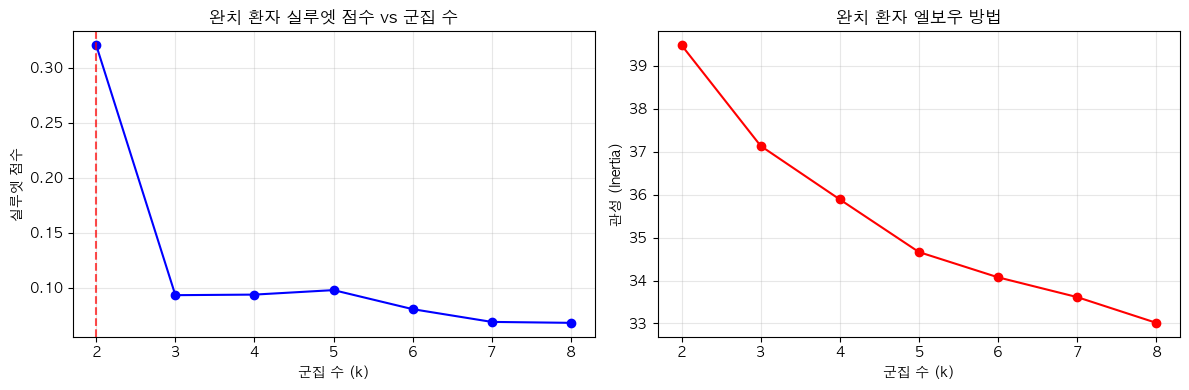

✅ 최적 군집 수: 2개

[5단계] 완치 환자만으로 최적 군집 형성...
완치 환자 2456명의 임베딩으로 2개 군집 형성...
완치 환자 군집 분포:
  군집 0: 337명
  군집 1: 2119명

[6단계] 모든 환자를 완치 기반 군집에 할당...
총 5120명 환자를 완치 기반 군집에 할당 중...

[7단계] 데이터프레임에 군집 정보 추가...

[8단계] 완치 환자 군집 특성 분석...

===== 완치 환자 (2456명) 군집 분포 =====
군집 0: 337명 (13.7%)
군집 1: 2119명 (86.3%)

군집 0 완치 환자 (337명) 특성:
- CC_vas: 2.46 ± 0.85
- CMO_before: 40.12 ± 8.61
- MMO_before: 46.03 ± 6.16
- dif_MMO_CMO: 5.91 ± 7.41
- Noise_Code: No-Noise (80.4%), Click (16.3%), Popping (3.3%)
- CC_pain_type: 통증 (54.6%), 뻐근함 (12.5%), 불편감 (1.8%)
- 습관_habit_type: 치아 접촉 줄이기 (99.4%), 이갈이 (0.3%), 잠들 때 이를 갉기는 습관 (0.3%)
- CC_location: 왼쪽 턱 (32.3%), 오른쪽 턱 (11.9%), 양쪽 턱 (6.5%)

군집 1 완치 환자 (2119명) 특성:
- CC_vas: 1.98 ± 1.09
- CMO_before: 45.16 ± 7.10
- MMO_before: 47.06 ± 5.56
- dif_MMO_CMO: 1.89 ± 4.01
- Noise_Code: No-Noise (73.9%), Click (24.2%), Popping (1.9%)
- CC_pain_type: 통증 (58.9%), 뻐근함 (18.0%), 뻐근감 (2.8%)
- 습관_habit_type: 치아 접촉 줄이기 (59.5%), 치아 갈기 (20.2%), 치아 접촉 (3.4%)
- CC_location: 왼쪽 턱 (54.7%), 오른쪽

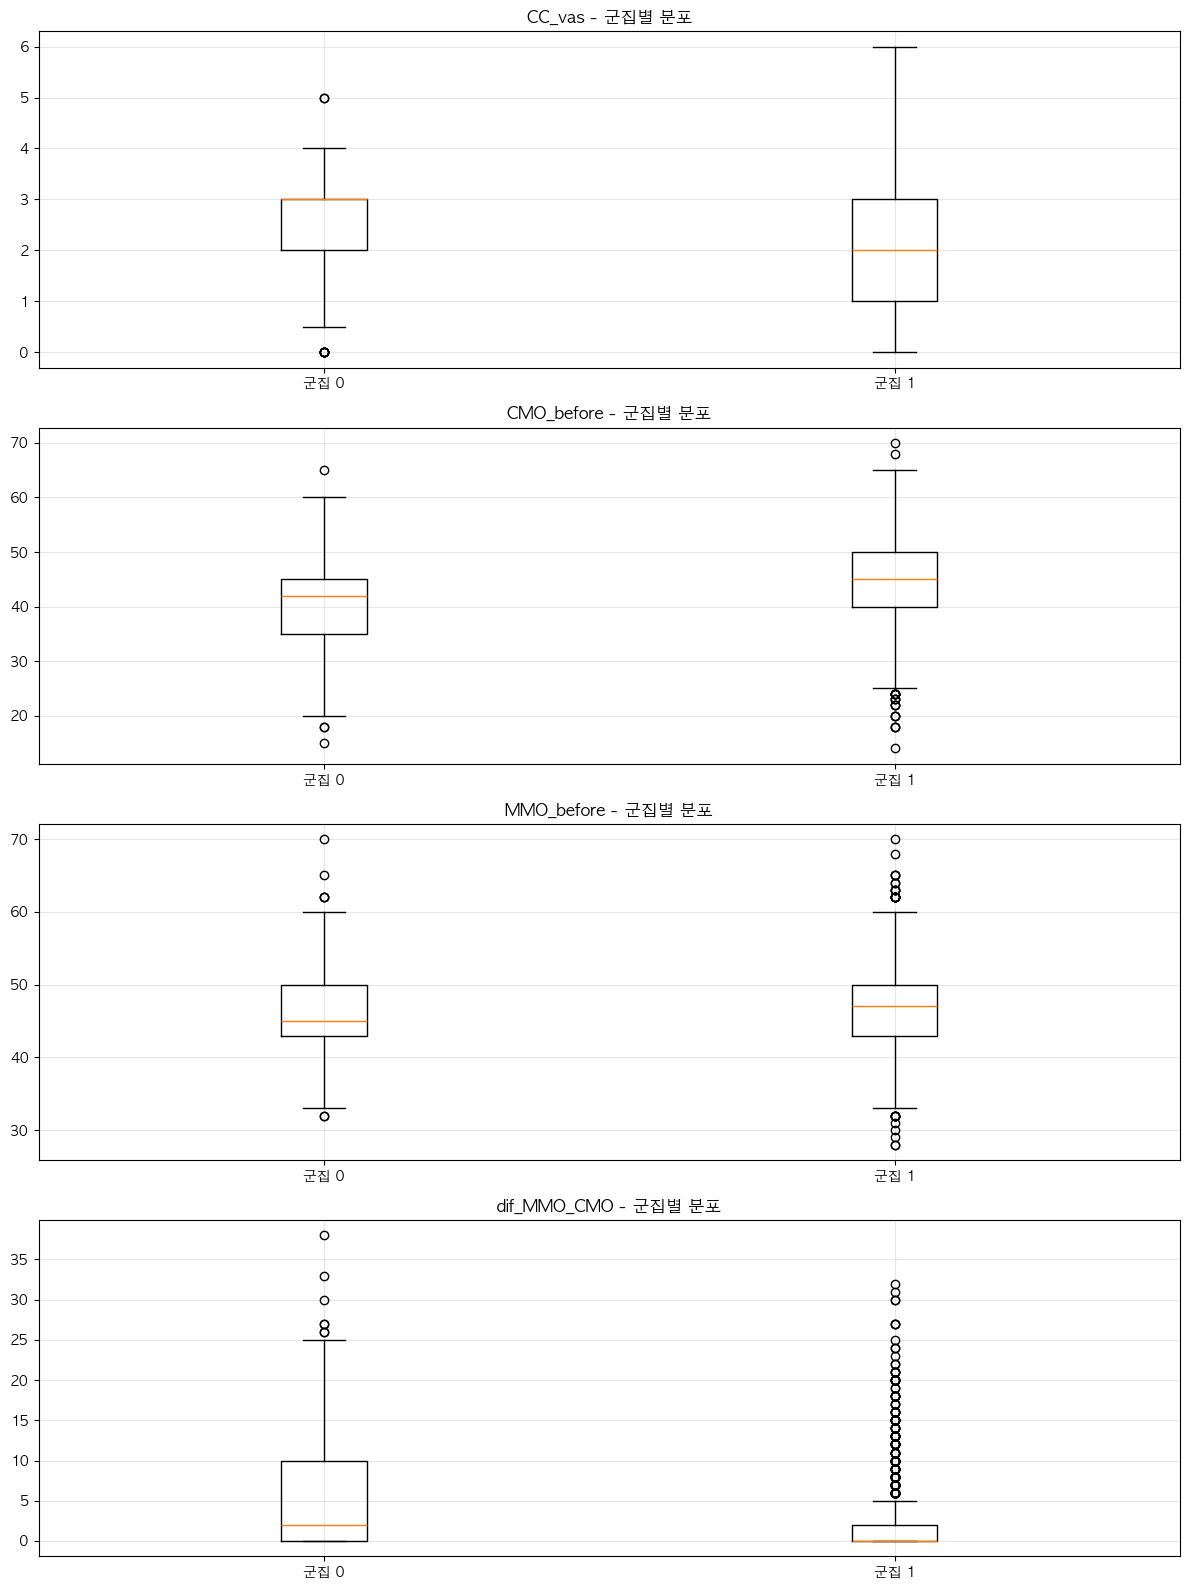


[9단계] 군집별 회복 궤적 분석...

군집 0 회복 궤적:
- CC_vas 변화:
  방문 1.0회차: 2.46 ± 0.85 (n=337.0)
- CMO_before 변화:
  방문 1.0회차: 40.12 ± 8.61 (n=337.0)
- MMO_before 변화:
  방문 1.0회차: 46.03 ± 6.16 (n=337.0)
- dif_MMO_CMO 변화:
  방문 1.0회차: 5.91 ± 7.41 (n=337.0)

군집 1 회복 궤적:
- CC_vas 변화:
  방문 1.0회차: 3.68 ± 2.19 (n=2119.0)
  방문 2.0회차: 3.48 ± 2.17 (n=2119.0)
  방문 3.0회차: 3.04 ± 2.07 (n=1852.0)
  방문 4.0회차: 2.79 ± 2.08 (n=1550.0)
  방문 5.0회차: 2.64 ± 2.00 (n=1283.0)
  방문 6.0회차: 2.66 ± 2.07 (n=1034.0)
  방문 7.0회차: 2.50 ± 1.93 (n=860.0)
  방문 8.0회차: 2.48 ± 1.96 (n=705.0)
  방문 9.0회차: 2.38 ± 1.94 (n=581.0)
  방문 10.0회차: 2.33 ± 1.93 (n=2496.0)
- CMO_before 변화:
  방문 1.0회차: 36.26 ± 10.23 (n=2119.0)
  방문 2.0회차: 38.84 ± 9.43 (n=2119.0)
  방문 3.0회차: 41.73 ± 8.42 (n=1852.0)
  방문 4.0회차: 43.27 ± 7.71 (n=1550.0)
  방문 5.0회차: 44.05 ± 7.23 (n=1283.0)
  방문 6.0회차: 44.52 ± 7.14 (n=1034.0)
  방문 7.0회차: 44.74 ± 7.02 (n=860.0)
  방문 8.0회차: 44.89 ± 6.81 (n=705.0)
  방문 9.0회차: 45.31 ± 6.72 (n=581.0)
  방문 10.0회차: 45.36 ± 6.72 (n=2496.0)
- MMO_befor

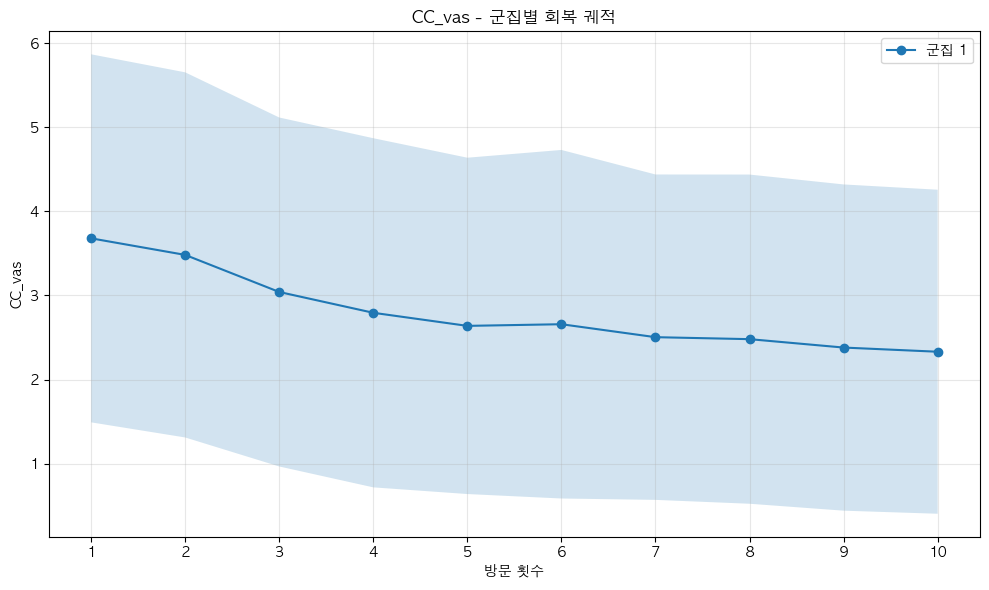

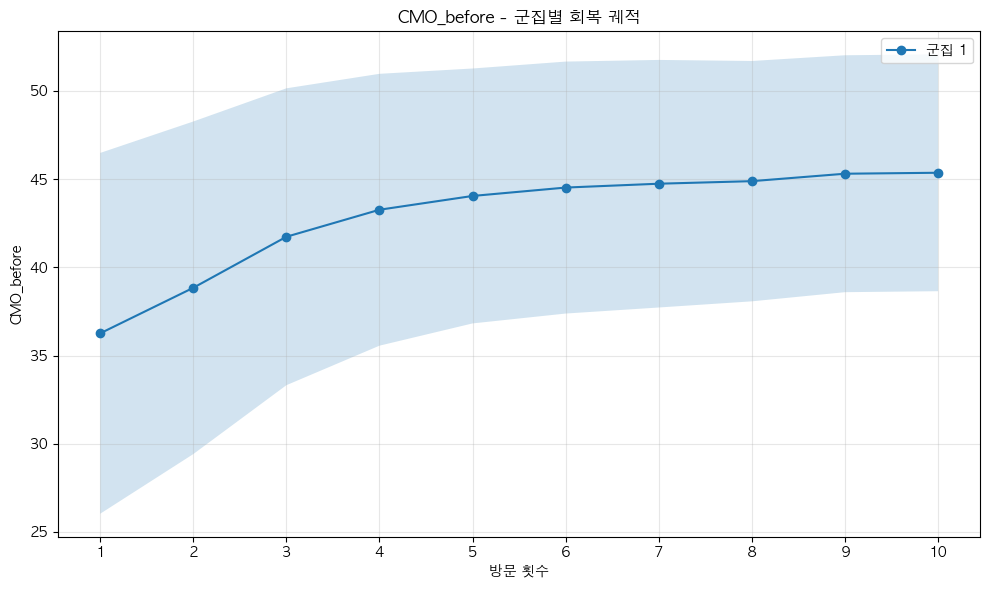

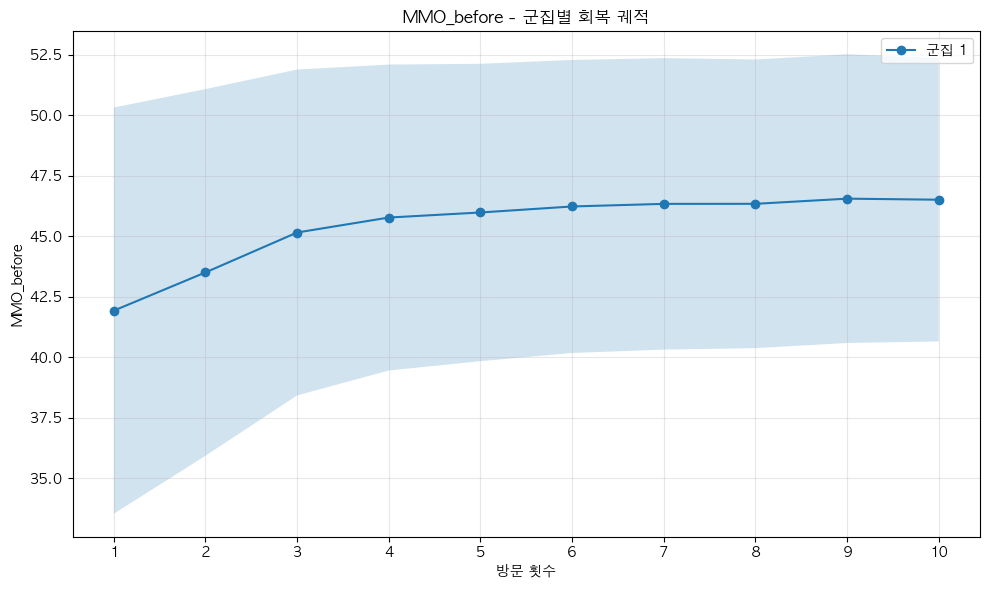

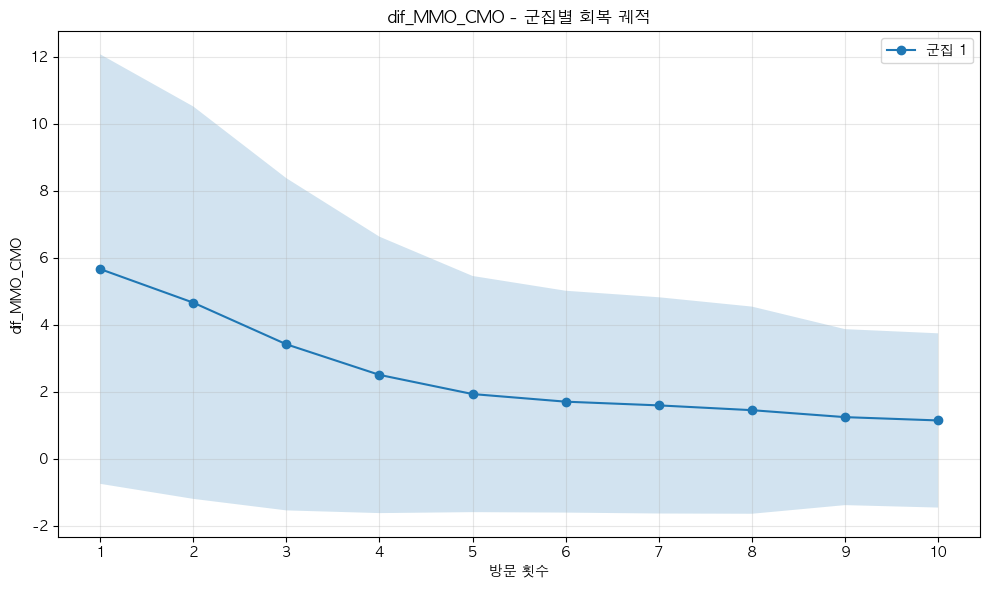


[10단계] 궤적 품질 검증...
궤적 품질 검증:
  군집 0: 지표 4개, 평균 방문 1.0회
  군집 1: 지표 4개, 평균 방문 10.0회

🎉 완치 환자 기반 궤적 분석 파이프라인 완료! (최적 군집: 2개)
궤적 중심 대시보드 초기화:
- 군집 수: 2개
- 완치 환자: 2456명

🎯 최종 결과:
- 최적 군집 수: 2개
- 완치 환자: 2456명
- 분석 완료!

===== 궤적 예측 테스트 =====

--- 환자 2111-105 궤적 예측 ---

===== 환자 2111-105 회복 궤적 예측 =====
현재 상태: 방문 13회차
군집 소속 확률: 군집 0: 45.8%, 군집 1: 54.2%
현재 임상 지표: CC_vas: 2.00, CMO_before: 43.00, MMO_before: 46.00, dif_MMO_CMO: 3.00
경고: 유효한 궤적 데이터가 없습니다. 예측할 수 없습니다.

--- 환자 2111-115 궤적 예측 ---

===== 환자 2111-115 회복 궤적 예측 =====
현재 상태: 방문 6회차
군집 소속 확률: 군집 0: 45.9%, 군집 1: 54.1%
현재 임상 지표: CC_vas: 10.00, CMO_before: 45.00, MMO_before: 55.00, dif_MMO_CMO: 10.00
경고: 유효한 궤적 데이터가 없습니다. 예측할 수 없습니다.

--- 환자 2111-119 궤적 예측 ---

===== 환자 2111-119 회복 궤적 예측 =====
현재 상태: 방문 1회차
군집 소속 확률: 군집 0: 54.5%, 군집 1: 45.5%
현재 임상 지표: CC_vas: 6.00, CMO_before: 42.00, MMO_before: 50.00, dif_MMO_CMO: 8.00
경고: 유효한 궤적 데이터가 없습니다. 예측할 수 없습니다.

🎉 최적 군집 수(2개) 기반 궤적 분석 완료!


In [38]:
# 최적 군집 수 자동 결정 궤적 분석 실행
embedding_batch_size = 100
max_clusters = 4  # 최대 탐색할 군집 수 (자동으로 최적값 결정)
recovery_threshold = 70
time_metric = '상대적'
alpha = 0.7

print("===== 완치 환자 기반 최적 궤적 분석 시작 =====")

# 최적 군집 수 자동 결정 궤적 분석 파이프라인 실행
trajectory_system = run_recovery_trajectory_pipeline(
    df, api_key, 
    max_clusters=max_clusters,  # 최대 8개까지 탐색
    recovery_threshold=recovery_threshold, 
    batch_size=embedding_batch_size, 
    alpha=alpha
)

# 궤적 중심 대시보드 생성
dashboard = create_trajectory_focused_dashboard(trajectory_system, df)

print(f"\n🎯 최종 결과:")
print(f"- 최적 군집 수: {trajectory_system['optimal_clusters']}개")
print(f"- 완치 환자: {len(trajectory_system['recovered_ids'])}명")
print(f"- 분석 완료!")

# 사용 예시
print("\n===== 궤적 예측 테스트 =====")
non_recovered_patients = [pid for pid in df['환자번호'].unique() 
                         if pid not in trajectory_system['recovered_ids']]

if len(non_recovered_patients) >= 3:
    test_patients = non_recovered_patients[:3]
    
    for patient_id in test_patients:
        print(f"\n--- 환자 {patient_id} 궤적 예측 ---")
        result = dashboard['predict_trajectory'](patient_id)
        if result and 'error' not in result:
            print(f"소속 군집: {result['most_likely_cluster']}/{trajectory_system['optimal_clusters']-1}")
            print(f"현재 상태: VAS={result['current_metrics'].get('CC_vas', 'N/A')}, "
                  f"MMO={result['current_metrics'].get('MMO_before', 'N/A')}")

print(f"\n🎉 최적 군집 수({trajectory_system['optimal_clusters']}개) 기반 궤적 분석 완료!")

In [39]:
create_interactive_dashboard(trajectory_system, df)

interactive(children=(Dropdown(description='환자:', options=(('환자 2111-04 ✅', '2111-04'), ('환자 2111-07 ✅', '2111…

✅ 대시보드 준비 완료


In [46]:
dashboard['predict_trajectory']('2111-04')



===== 환자 2111-04 회복 궤적 예측 =====
현재 상태: 방문 4회차
군집 소속 확률: 군집 0: 45.8%, 군집 1: 54.2%
현재 임상 지표: CC_vas: 3.00, CMO_before: 38.00, MMO_before: 48.00, dif_MMO_CMO: 10.00
경고: 유효한 궤적 데이터가 없습니다. 예측할 수 없습니다.


{'patient_id': '2111-04', 'error': '유효한 궤적 데이터 없음'}

In [45]:
df.환자번호

0        2111-04
1        2111-04
2        2111-04
3        2111-04
4        2111-07
          ...   
28157    2405-86
28158    2405-88
28159    2405-89
28160    2405-96
28161    2405-99
Name: 환자번호, Length: 27900, dtype: object